In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

In [ ]:

# works out correlation matrix for returns in window size K ending at t - so up to time t
def correlation_matrix(returns, t, K, eps=0.0, active=None):
    t = pd.to_datetime(t)
    windowed_returns = returns.loc[t - pd.Timedelta(days=K*1.5): t].dropna(how='all')
    window = windowed_returns.dropna(axis=1, how="all")
    if active is not None:
        window = window[active]

    if eps == 0.0:
        window = window.loc[:, ~(window.fillna(0.0) == 0.0).all(axis=0)]
    else:
        window = window.loc[:, ~(window.fillna(0.0).abs() <= eps).all(axis=0)]
    active_cols = window.columns.tolist()

    #scaler = MinMaxScaler(feature_range=(0, 1))
    #windowed_returns = scaler.fit_transform(windowed_returns)
    #windowed_returns = (windowed_returns - windowed_returns.min()) / (windowed_returns.max() - windowed_returns.min() + 1e-8)
    corr_matrix = window.corr().values
    corr_matrix = np.nan_to_num(corr_matrix, nan=0.0, posinf=0.0, neginf=0.0)

    return corr_matrix, active_cols

# function takes in historical returns for each t with window size K 
# and computes initial node embeddings as H = US where Y = U S V^T is the SVD of the returns matrix Y

def compute_initial_node_embeddings(returns, t, K, eps=0.0, active=None, device='cuda' if torch.cuda.is_available() else 'cpu'):
    node_embeddings = {}
    t = pd.to_datetime(t)
    windowed_returns = returns.loc[t - pd.Timedelta(days=K*1.5): t].dropna(how='all')
    
    # Check if window is empty
    if windowed_returns.empty:
        return {}, []

    window = windowed_returns.dropna(axis=1, how="all")
    if active is not None:
        # Intersect active with available columns
        valid_active = [c for c in active if c in window.columns]
        if not valid_active:
            return {}, []
        window = window[valid_active]
        
    if window.shape[0] < 2 or window.shape[1] == 0: # Need at least some data
        return {}, []

    if eps == 0.0:
        window = window.loc[:, ~(window.fillna(0.0) == 0.0).all(axis=0)]
    else:
        window = window.loc[:, ~(window.fillna(0.0).abs() <= eps).all(axis=0)]

    active_cols = window.columns.tolist()
    if not active_cols:
        return {}, []
    
    window_tensor = torch.tensor(window.values, dtype=torch.float32, device=device)

    # Use torch.linalg.svd (runs on GPU if device is 'cuda')
    U, S, Vh = torch.linalg.svd(window_tensor, full_matrices=False)
    
    # H = V @ S (V is Vh.mH, the conjugate transpose)
    H = Vh.mH @ torch.diag(S)
    H = H[:, :10]

    if H.shape[1] < 10:
        padding = torch.zeros((H.shape[0], 10 - H.shape[1]), device=device)
        H = torch.cat([H, padding], dim=1)
    
    # MinMax Scaling on GPU
    h_min = H.min(dim=0, keepdim=True).values
    h_max = H.max(dim=0, keepdim=True).values
    H = (H - h_min) / (h_max - h_min + 1e-8)

    # Convert back to dictionary (keeping tensors for subsequent model steps)
    for i, stock in enumerate(active_cols):
        node_embeddings[stock] = H[i, :].detach()

    for stock in node_embeddings:
        node_embeddings[stock] = np.array(node_embeddings[stock])
        
    return node_embeddings, active_cols

    # Handle case where SVD returns fewer than 10 components
    # if H.shape[1] < 10:
    #     padding = np.zeros((H.shape[0], 10 - H.shape[1]))
    #     H = np.hstack([H, padding])
    
    # scaler = MinMaxScaler(feature_range=(0, 1))
    # H = scaler.fit_transform(H)

    # for i, stock in enumerate(active_cols):
    #     node_embeddings[stock] = H[i, :] # contains only one embedding per stock at time t, embedding shape (10,)
        
    # here - store the array directly in the list to match our structure

        
    #return node_embeddings, active_cols

In [ ]:
# layer gives me attention weights for edges - gives A_+ and A_-
class GATLayer(torch.nn.Module):
    
    src_nodes_dim = 0  # position of source nodes in edge index
    trg_nodes_dim = 1  # position of target nodes in edge index

    nodes_dim = 0      # node dimension (the position of "N" in tensor)
    head_dim = 2       # attention head dim

    def __init__(self, num_in_features, num_out_features, num_of_heads, concat=True, activation=nn.ELU(),
                 dropout_prob=0.1, add_skip_connection=True, bias=True, log_attention_weights=False):

        super().__init__()

        self.num_of_heads = num_of_heads # number of attention heads - mine has a positive and negative head so 2
        self.num_out_features = num_out_features
        self.concat = concat  # whether we should concatenate or average the attention heads
        self.add_skip_connection = add_skip_connection

        # treat this one matrix as num_of_heads independent W matrices
        self.linear_proj = nn.Linear(num_in_features, num_of_heads * num_out_features, bias=False)

        # After we concatenate target node (node i) and source node (node j) we apply the additive scoring function
        # which gives us un-normalized score "e". we split the "a" vector - but the semantics remain the same.
        # Basically instead of doing [x, y] (concatenation, x/y are node feature vectors) and dot product with "a"
        # we instead do a dot product between x and "a_left" and y and "a_right" and we sum them up
        # these params will be updated during training (below)
        self.scoring_fn_target = nn.Parameter(torch.Tensor(1, num_of_heads, num_out_features))
        self.scoring_fn_source = nn.Parameter(torch.Tensor(1, num_of_heads, num_out_features))

        # Bias is definitely not crucial to GAT - feel free to experiment (I pinged the main author, Petar, on this one)
        if bias and concat:
            self.bias = nn.Parameter(torch.Tensor(num_of_heads * num_out_features))
        elif bias and not concat:
            self.bias = nn.Parameter(torch.Tensor(num_out_features))
        else:
            self.register_parameter('bias', None) # no bias

        if add_skip_connection:
            self.skip_proj = nn.Linear(num_in_features, num_of_heads * num_out_features, bias=False)
        else:
            self.register_parameter('skip_proj', None)


        self.leakyReLU = nn.LeakyReLU(0.2)  # using 0.2 as in the paper, no need to expose every setting
        self.activation = activation
        # Probably not the nicest design but I use the same module in 3 locations, before/after features projection
        # and for attention coefficients. Functionality-wise it's the same as using independent modules.
        self.dropout = nn.Dropout(p=dropout_prob)

        self.log_attention_weights = log_attention_weights  # whether we should log the attention weights
        self.attention_weights = None  # for later visualization purposes, I cache the weights here

        self.init_params()
        
    def forward(self, data):
        # Step 1: Linear Projection + regularization

        in_nodes_features, edge_index, corr = data  # unpack data - corr contains N x N correlation matrix at time t 
        num_of_nodes = in_nodes_features.shape[self.nodes_dim]
        assert edge_index.shape[0] == 2, f'Expected edge index with shape=(2,E) got {edge_index.shape}'

        # shape = (N, FIN) where N - number of nodes in the graph, FIN - number of input features per node
        # apply the dropout to all of the input node features (as mentioned in the paper)
        # can try without this part as an experiment
        in_nodes_features = self.dropout(in_nodes_features)

        # shape = (N, FIN) * (FIN, NH*FOUT) -> (N, NH, FOUT) where NH - number of heads, FOUT - num of output features
        # We project the input node features into NH independent output features (one for each attention head)
        nodes_features_proj = self.linear_proj(in_nodes_features).view(-1, self.num_of_heads, self.num_out_features)

        # can try without this
        nodes_features_proj = self.dropout(nodes_features_proj)  # in the official GAT imp they did dropout here as well

        # Step 2:edge attention calculation

        # Apply the scoring function (* represents element-wise (a.k.a. Hadamard) product)
        # shape = (N, NH, FOUT) * (1, NH, FOUT) -> (N, NH, 1) -> (N, NH) because sum squeezes the last dimension
        # Optimization note: torch.sum() is as performant as .sum() in my experiments
        scores_source = (nodes_features_proj * self.scoring_fn_source).sum(dim=-1)
        scores_target = (nodes_features_proj * self.scoring_fn_target).sum(dim=-1)

        # We simply copy (lift) the scores for source/target nodes based on the edge index. Instead of preparing all
        # the possible combinations of scores we just prepare those that will actually be used and those are defined
        # by the edge index.
        # scores shape = (E, NH), nodes_features_proj_lifted shape = (E, NH, FOUT), E - number of edges in the graph
        scores_source_lifted, scores_target_lifted, nodes_features_proj_lifted = self.lift(scores_source, scores_target, nodes_features_proj, edge_index)
        scores_per_edge = self.leakyReLU(scores_source_lifted + scores_target_lifted)
        #scores_per_edge = self.mask_function(scores_per_edge, edge_index)
        
        src = edge_index[self.src_nodes_dim]
        trg = edge_index[self.trg_nodes_dim]

        # corr is N x N, extract per-edge correlations (E,)
        corr_e = corr[src, trg] 
        # masks (E, 1) so they broadcast across heads
        mask_pos = (corr_e >= 0).float().unsqueeze(-1)
        mask_neg = (corr_e < 0).float().unsqueeze(-1)

        # two masked attentions, each normalized over the same target-neighborhood
        att_pos = self.neighborhood_aware_softmax(scores_per_edge, trg, num_of_nodes, mask_pos)
        att_neg = self.neighborhood_aware_softmax(scores_per_edge, trg, num_of_nodes, mask_neg)

        # treat them as two separate sign heads
        attentions_per_edge = torch.cat([att_pos, att_neg], dim=1)  # (E, 2*NH, 1)
        attentions_per_edge = self.dropout(attentions_per_edge)

        return attentions_per_edge
        
    def neighborhood_aware_softmax(self, scores_per_edge, trg_index, num_of_nodes, mask):
        # Calculate the numerator. Make logits <= 0 so that e^logit <= 1 (this will improve the numerical stability)
        scores_per_edge = scores_per_edge - scores_per_edge.max()
        exp_scores_per_edge = scores_per_edge.exp()  # softmax
        exp_scores_per_edge = exp_scores_per_edge * mask

        # Calculate the denominator. shape = (E, NH)
        neigborhood_aware_denominator = self.sum_edge_scores_neighborhood_aware(exp_scores_per_edge, trg_index, num_of_nodes)
        # 1e-16 is theoretically not needed but is only there for numerical stability (avoid div by 0) - due to the
        # possibility of the computer rounding a very small number all the way to 0.
        attentions_per_edge = exp_scores_per_edge / (neigborhood_aware_denominator + 1e-16)
        # shape = (E, NH) -> (E, NH, 1) so that we can do element-wise multiplication with projected node features
        return attentions_per_edge.unsqueeze(-1)

    def sum_edge_scores_neighborhood_aware(self, exp_scores_per_edge, trg_index, num_of_nodes):
        # The shape must be the same as in exp_scores_per_edge (required by scatter_add_) i.e. from E -> (E, NH)
        trg_index_broadcasted = self.explicit_broadcast(trg_index, exp_scores_per_edge)
        # shape = (N, NH), where N is the number of nodes and NH the number of attention heads
        size = list(exp_scores_per_edge.shape)  # convert to list otherwise assignment is not possible
        size[self.nodes_dim] = num_of_nodes
        neighborhood_sums = torch.zeros(size, dtype=exp_scores_per_edge.dtype, device=exp_scores_per_edge.device)
        # position i will contain a sum of exp scores of all the nodes that point to the node i (as dictated by the
        # target index)
        neighborhood_sums.scatter_add_(self.nodes_dim, trg_index_broadcasted, exp_scores_per_edge)
        # Expand again so that we can use it as a softmax denominator. e.g. node i's sum will be copied to
        # all the locations where the source nodes pointed to i (as dictated by the target index)
        # shape = (N, NH) -> (E, NH)
        return neighborhood_sums.index_select(self.nodes_dim, trg_index)

    def aggregate_neighbors(self, nodes_features_proj_lifted_weighted, edge_index, in_nodes_features, num_of_nodes):
        size = list(nodes_features_proj_lifted_weighted.shape)  # convert to list otherwise assignment is not possible
        size[self.nodes_dim] = num_of_nodes  # shape = (N, NH, FOUT)
        out_nodes_features = torch.zeros(size, dtype=in_nodes_features.dtype, device=in_nodes_features.device)

        # shape = (E) -> (E, NH, FOUT)
        trg_index_broadcasted = self.explicit_broadcast(edge_index[self.trg_nodes_dim], nodes_features_proj_lifted_weighted)
        # aggregation step - we accumulate projected, weighted node features for all the attention heads
        # shape = (E, NH, FOUT) -> (N, NH, FOUT)
        out_nodes_features.scatter_add_(self.nodes_dim, trg_index_broadcasted, nodes_features_proj_lifted_weighted)

        return out_nodes_features

    def lift(self, scores_source, scores_target, nodes_features_matrix_proj, edge_index):
        #Lift duplicates certain vectors depending on the edge index.
        #One of the tensor dims goes from N -> E (that's where the "lift" comes from)

        src_nodes_index = edge_index[self.src_nodes_dim]
        trg_nodes_index = edge_index[self.trg_nodes_dim]

        # Using index_select is faster than "normal" indexing (scores_source[src_nodes_index]) in PyTorch!
        scores_source = scores_source.index_select(self.nodes_dim, src_nodes_index)
        scores_target = scores_target.index_select(self.nodes_dim, trg_nodes_index)
        nodes_features_matrix_proj_lifted = nodes_features_matrix_proj.index_select(self.nodes_dim, src_nodes_index)

        return scores_source, scores_target, nodes_features_matrix_proj_lifted

    def explicit_broadcast(self, this, other):
        # Append singleton dimensions until this.dim() == other.dim()
        for _ in range(this.dim(), other.dim()):
            this = this.unsqueeze(-1)

        # Explicitly expand so that shapes are the same
        return this.expand_as(other)

    def init_params(self): # TODO: try changing initialization
        """
        The reason we're using Glorot (aka Xavier uniform) initialization is because it's a default TF initialization:
            https://stackoverflow.com/questions/37350131/what-is-the-default-variable-initializer-in-tensorflow

        The original repo was developed in TensorFlow (TF) and they used the default initialization.
        Feel free to experiment - there may be better initializations depending on your problem.

        """
        nn.init.xavier_uniform_(self.linear_proj.weight)
        nn.init.xavier_uniform_(self.scoring_fn_target)
        nn.init.xavier_uniform_(self.scoring_fn_source)

        if self.bias is not None:
            torch.nn.init.zeros_(self.bias)



In [4]:
from torch.optim import Adam

class GAT(torch.nn.Module): # gives me attention weights matrices for edges - gives A_+ and A_-

    def __init__(self, num_of_layers, num_heads_per_layer, num_features_per_layer, add_skip_connection=True, bias=True,
                 dropout=0.1, log_attention_weights=False):
        super().__init__()
        assert num_of_layers == len(num_heads_per_layer) == len(num_features_per_layer) - 1, f'Enter valid arch params.'

        num_heads_per_layer = [1] + num_heads_per_layer  # trick - so that I can nicely create GAT layers below

        gat_layers = []  # collect GAT layers
        for i in range(num_of_layers):
            layer = GATLayer(
                num_in_features=num_features_per_layer[i] * num_heads_per_layer[i],  # consequence of concatenation
                num_out_features=num_features_per_layer[i+1],
                num_of_heads=num_heads_per_layer[i+1],
                concat=True if i < num_of_layers - 1 else False,  # last GAT layer does mean avg, the others do concat
                activation=nn.ELU() if i < num_of_layers - 1 else None,  # last layer just outputs raw scores
                dropout_prob=dropout,
                add_skip_connection=add_skip_connection,
                bias=bias,
                log_attention_weights=log_attention_weights
            )
            gat_layers.append(layer)

        self.gat_net = nn.Sequential(
            *gat_layers,
        )

    # data is just a (in_nodes_features, edge_index) tuple:

    def forward(self, data):
        return self.gat_net(data)

In [5]:

class DiffusionConvLayer(nn.Module):
    
    #At each diffusion step s, compute:
    #Z_+ = sum_{s=0}^{S-1} θ_s,1 × (A_+_norm)^s × X
    #Z_- = sum_{s=0}^{S-1} θ_s,2 × (A_-_norm)^s × X
    #Output: [Z_+ || Z_-] concatenated
    
    def __init__(self, in_features, out_channels, num_diffusion_steps=1, bias=True):
    #in_features: Input feature dimension = d
    #out_channels: Number of output channels per network (Q)
    #num_diffusion_steps: Number of diffusion steps (S)
        super().__init__()
        
        self.in_features = in_features
        self.out_channels = out_channels
        self.num_diffusion_steps = num_diffusion_steps
        
        # Learnable diffusion filters: one set for positive, one for negative
        # Shape: (S, d, Q) for each
        self.theta_pos = nn.Parameter(
            torch.Tensor(num_diffusion_steps, in_features, out_channels)
        )
        self.theta_neg = nn.Parameter(
            torch.Tensor(num_diffusion_steps, in_features, out_channels)
        )
        
        if bias:
            self.bias_pos = nn.Parameter(torch.Tensor(out_channels))
            self.bias_neg = nn.Parameter(torch.Tensor(out_channels))
        else:
            self.register_parameter('bias', None)
            
        self.reset_parameters()
        
    def reset_parameters(self):
        nn.init.xavier_uniform_(self.theta_pos)
        nn.init.xavier_uniform_(self.theta_neg)
        if self.bias_pos is not None:
            nn.init.zeros_(self.bias_pos)
        if self.bias_neg is not None:
            nn.init.zeros_(self.bias_neg)
    
    def forward(self, X_pos, X_neg, A_pos, A_neg):
        N = X_pos.shape[0] # X is N x d
        
        # Normalize adjacency matrices for random walk
        # D^(-1) × A
        D_pos = A_pos.sum(dim=1, keepdim=True) + 1e-8  # (N, 1)
        D_neg = A_neg.sum(dim=1, keepdim=True) + 1e-8
        A_t_pos_norm = A_pos / D_pos  # (N, N)
        A_neg_norm = A_neg / D_neg
        
        # Initialize outputs
        Z_pos = torch.zeros(N, self.out_channels, device=X_pos.device) # 0's
        Z_neg = torch.zeros(N, self.out_channels, device=X_neg.device)

        # Positive diffusion
        A_power = torch.eye(N, device=X_pos.device)  # A^0 = Identity matrix
        for s in range(self.num_diffusion_steps):
            # θ_s × (A^s × X) for each output channel where s is the diffusion step
            # A_power: (N, N), X: (N, d), theta_pos[s]: (d, Q)
            diffused = A_power @ X_pos  # (N, d)
            Z_pos += diffused @ self.theta_pos[s]  # (N, d) @ (d, Q) = (N, Q) 
            A_power = A_power @ A_t_pos_norm  # Update A^s
        
        # Negative diffusion
        A_power = torch.eye(N, device=X_neg.device)
        for s in range(self.num_diffusion_steps):
            diffused = A_power @ X_neg
            Z_neg += diffused @ self.theta_neg[s]
            A_power = A_power @ A_neg_norm
        
        # Concatenate positive and negative outputs
        #Z = torch.cat([Z_pos, Z_neg], dim=1)  # (N, 2Q)

        if self.bias_pos is not None:
            Z_pos = Z_pos + self.bias_pos

        if self.bias_neg is not None:
            Z_neg = Z_neg + self.bias_neg

        return Z_pos, Z_neg # each is (N, Q)


In [ ]:
class SpatialEncoder(nn.Module):
    
    def __init__(self, in_features_dim, hidden_channels, num_diffusion_steps=1, 
                 dropout=0.1):
        #hidden_channels: List of output channels for each layer, e.g., [32, 16] means 2 layers with 32 and 16 channels
        #num_diffusion_steps: Diffusion steps for each layer

        super().__init__()
        
        layers = []
        channels = [in_features_dim] + hidden_channels
        
        for i in range(len(channels) - 1):
            layers.append(
                DiffusionConvLayer(
                    in_features=channels[i],
                    out_channels=channels[i+1],
                    num_diffusion_steps=num_diffusion_steps
                )
            )
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout)) # dropout after each layer for regularization
        
        self.layers = nn.ModuleList(layers)
        
    def forward(self, Z_pos, Z_neg, A_pos, A_neg):

        #input Z_pos and Z_neg are just X at the start
        for layer in self.layers:
            if isinstance(layer, DiffusionConvLayer):
                Z_pos, Z_neg = layer(Z_pos, Z_neg, A_pos, A_neg)
            else:
                Z_pos = layer(Z_pos)
                Z_neg = layer(Z_neg)
        return Z_pos, Z_neg

class GraphConvGRUCell(nn.Module):

    def __init__(self, input_dim, hidden_dim, num_diffusion_steps=1):

        super().__init__()
        
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        
        # Diffusion layers for reset gate
        self.conv_r = DiffusionConvLayer(
            in_features=input_dim + hidden_dim,
            out_channels=hidden_dim,
            num_diffusion_steps=num_diffusion_steps
        )
        
        # Diffusion layers for update gate
        self.conv_u = DiffusionConvLayer(
            in_features=input_dim + hidden_dim,
            out_channels=hidden_dim,
            num_diffusion_steps=num_diffusion_steps
        )
        
        # Diffusion layers for candidate activation
        self.conv_c = DiffusionConvLayer(
            in_features=input_dim + hidden_dim,
            out_channels=hidden_dim,
            num_diffusion_steps=num_diffusion_steps
        )
        
    def forward(self, x_t_pos, x_t_neg, h_prev_pos, h_prev_neg, A_pos, A_neg):
        # Concatenate input and previous hidden state
        combined_pos = torch.cat([x_t_pos, h_prev_pos], dim=1)  # (N, input_dim + hidden_dim)
        combined_neg = torch.cat([x_t_neg, h_prev_neg], dim=1)  # (N, input_dim + hidden_dim)

        # Reset gate: r_t = sigmoid(DiffConv([x_t, h_{t-1}]))
        r_pos, r_neg = self.conv_r(combined_pos, combined_neg, A_pos, A_neg)  # (N, hidden_dim) each
        r_t_pos, r_t_neg = torch.sigmoid(r_pos), torch.sigmoid(r_neg)  # (N, hidden_dim) each

        # Update gate: u_t = sigmoid(DiffConv([x_t, h_{t-1}]))
        u_pos, u_neg = self.conv_u(combined_pos, combined_neg, A_pos, A_neg)
        u_t_pos, u_t_neg = torch.sigmoid(u_pos), torch.sigmoid(u_neg)  # (N, hidden_dim) each

        # Candidate: c_t = tanh(DiffConv([x_t, r_t * h_{t-1}]))
        #positive
        h_tilde_pos = r_t_pos * h_prev_pos  # Element-wise product
        h_tilde_neg = r_t_neg * h_prev_neg  # Element-wise product
        combined_c_pos = torch.cat([x_t_pos, h_tilde_pos], dim=1)
        combined_c_neg = torch.cat([x_t_neg, h_tilde_neg], dim=1)
        c_pos, c_neg = self.conv_c(combined_c_pos, combined_c_neg, A_pos, A_neg)
        c_t_pos, c_t_neg = torch.tanh(c_pos), torch.tanh(c_neg)  # (N, hidden_dim) each

        # Update hidden state: h_t = u_t * h_{t-1} + (1 - u_t) * c_t
        h_t_pos = u_t_pos * h_prev_pos + (1 - u_t_pos) * c_t_pos
        h_t_neg = u_t_neg * h_prev_neg + (1 - u_t_neg) * c_t_neg
        
        return h_t_pos, h_t_neg
    

In [ ]:
class StructuralAnomalyBranch(nn.Module):
    """
    Dedicated structural encoder — completely decoupled from h.
    Inner product decoder now works because z_struct IS trained to
    encode structural similarity.
    """
    def __init__(self, latent_dim=16):
        super().__init__()
        # 4 fixed-dim structural features per node → latent
        self.encoder = nn.Sequential(
            nn.Linear(4, latent_dim),
            nn.ReLU(),
            nn.Linear(latent_dim, latent_dim)
        )

    def _structural_features(self, A_pos, A_neg):
        N = A_pos.shape[0]

        pos_deg = A_pos.sum(dim=1, keepdim=True) / (N - 1 + 1e-8)   # (N,1) # A_pos contains weights 
        neg_deg = A_neg.sum(dim=1, keepdim=True) / (N - 1 + 1e-8)   # (N,1)

        pos_deg_top = (A_pos > 0).float().sum(dim=1, keepdim=True)
        neg_deg_top = (A_neg > 0).float().sum(dim=1, keepdim=True)
        # Local clustering: diag(A^3) / (d*(d-1))
        pos_tri  = torch.diag(A_pos @ A_pos @ A_pos).unsqueeze(1)
        neg_tri  = torch.diag(A_neg @ A_neg @ A_neg).unsqueeze(1)
        
        pos_clus = pos_tri / (pos_deg * (N - 1) * (pos_deg * (N - 1) - 1) + 1e-8)
        neg_clus = neg_tri / (neg_deg * (N - 1) * (neg_deg * (N - 1) - 1) + 1e-8)

        return torch.cat([pos_deg, neg_deg, pos_clus, neg_clus], dim=1)  # (N, 4)

    def forward(self, A_pos, A_neg):
        feats   = self._structural_features(A_pos, A_neg)      # (N, 4)
        z       = self.encoder(feats)                           # (N, latent_dim)
        A_hat_pos = torch.sigmoid( z @ z.T)                    # (N, N)
        A_hat_neg = torch.sigmoid(-z @ z.T)
        
        err_pos = torch.norm(A_pos - A_hat_pos, dim=1)         # (N,)
        err_neg = torch.norm(A_neg - A_hat_neg, dim=1)
        struct_error = 0.5 * (err_pos + err_neg)  
        N = A_pos.shape[0]
        loss = torch.mean(struct_error ** 2) / N
        return struct_error, loss

In [ ]:
class ReconstructionDecoder(nn.Module):
    
    def __init__(self, hidden_dim, feature_dim):

        super().__init__()
                
        # Feature reconstruction: h_t → X_t (pred)
        self.feature_decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, feature_dim)
        )
        
        # Structure reconstruction is done via inner product: A_hat = sigmoid(h × h^T)
        # No parameters needed
        
    def forward(self, h_pos, h_neg, X_t, A_t_pos, A_t_neg):

        N = h_pos.shape[0]
        
        h_t = h_pos + h_neg
        # Reconstruct features
        X_hat = self.feature_decoder(h_t)  # (N, d)
        
        # Feature reconstruction error per node
        feature_error = torch.norm(X_t - X_hat, dim=1)  # (N,)
        
        # Reconstruct structure if requested
        if A_t_pos is not None and A_t_neg is not None:
            # Â = sigmoid(h × h^T)
            # A_hat_pos = torch.sigmoid(h_pos @ h_pos.T)  # (N, N)
            # A_hat_neg = torch.sigmoid(h_neg @ h_neg.T)  # (N, N)
            
            # # Structure reconstruction error per node (row-wise)
            # struct_err_pos = torch.norm(A_t_pos - A_hat_pos, dim=1)  # (N,)
            # struct_err_neg = torch.norm(A_t_neg - A_hat_neg, dim=1)  # (N,)
            # structure_error = 0.5 * (struct_err_pos + struct_err_neg)

            # loss_struct_pos = torch.mean((A_t_pos - A_hat_pos) ** 2)
            # loss_struct_neg = torch.mean((A_t_neg - A_hat_neg) ** 2)
            # loss_struct = 0.5 * (loss_struct_pos + loss_struct_neg)
            
            # Combined error (alpha balances feature vs structure)
        
            combined_error = feature_error 
            
            # Compute losses
            loss_feat = torch.mean(feature_error ** 2)
            total_loss = loss_feat 
            
        else:
            A_hat_pos = None
            A_hat_neg = None
            combined_error = feature_error
            total_loss = torch.mean(feature_error ** 2)
        
        # Normalize errors to [0, 1] range (bubble signals per node)
        signals = (combined_error - combined_error.min()) / (combined_error.max() - combined_error.min() + 1e-8)
        #signals = combined_error
        return total_loss, signals


class BubbleDetectionModel(nn.Module):
    def __init__(self, 
                 gat_config,
                 feature_dim,
                 embedding_dim,
                 encoder_channels, # list of channels for spatial encoder
                 hidden_dim,
                 num_diffusion_steps=1,
                 alpha=1.0,
                 use_structure_recon=True,
                 dropout=0.1):

        super().__init__()
        
        self.feature_dim = feature_dim # d
        self.embedding_dim = embedding_dim # L - dim of PCA embeddings
        self.hidden_dim = hidden_dim # GRU hidden dim
        self.alpha = alpha
        # 1. GAT for attention weights (you already have this)
        self.gat = GAT(
            num_of_layers=gat_config['num_layers'], # gat_config: Dict with GAT parameters (num_layers, heads, features)
            num_heads_per_layer=gat_config['heads'],
            num_features_per_layer=gat_config['features'],
            dropout=dropout
        )
        
        # 2. Spatial encoder
        self.spatial_encoder = SpatialEncoder(
            in_features_dim=feature_dim,
            hidden_channels=encoder_channels,
            num_diffusion_steps=num_diffusion_steps,
            dropout=dropout
        )
        
        # Output dimension of spatial encoder 
        spatial_out_dim = encoder_channels[-1]
        
        # 3. GRU cell (we'll add embedding_dim because we concatenate H_t)
        self.gru = GraphConvGRUCell(
            input_dim=spatial_out_dim + embedding_dim,
            hidden_dim=hidden_dim,
            num_diffusion_steps=num_diffusion_steps
        )
        self.struct_branch = StructuralAnomalyBranch(latent_dim=16)
        # 4. Decoder
        self.decoder = ReconstructionDecoder(
            hidden_dim=hidden_dim,
            feature_dim=feature_dim,
            use_structure_recon=use_structure_recon
        )

    def forward(self, X_t, H_t, edge_index, corr_matrix, h_prev_pos=None, h_prev_neg=None, A_t_pos=None, A_t_neg=None):

        N = X_t.shape[0]
        
        # Initialise hidden state if None
        if h_prev_pos is None:
            h_prev_pos = torch.zeros(N, self.hidden_dim, device=X_t.device)
        if h_prev_neg is None:
            h_prev_neg = torch.zeros(N, self.hidden_dim, device=X_t.device)

        # Step 1: Compute attention weights with GAT
        # GAT expects (features, edge_index, corr_matrix)
        attention_weights = self.gat((H_t, edge_index, corr_matrix))  # (E, 2*NH, 1)
        
        # Convert edge attention to adjacency matrices
        A_pos, A_neg = self.attention_to_adjacency(
            attention_weights, edge_index, N
        )
        
        # Step 2: Spatial encoding
        Z_t_pos, Z_t_neg = self.spatial_encoder(X_t,X_t, A_pos, A_neg)  # (N, 2Q)
        
        # Step 3: Concatenate with PCA embeddings (bypass connection)
        Z_t_full_pos = torch.cat([Z_t_pos, H_t], dim=1)  # (N, 2Q + L)
        Z_t_full_neg = torch.cat([Z_t_neg, H_t], dim=1)  # (N, 2Q + L)
        
        # Step 4: GRU update
        h_t_pos, h_t_neg = self.gru(Z_t_full_pos, Z_t_full_neg, h_prev_pos, h_prev_neg, A_pos, A_neg)  # (N, hidden_dim)
        
        # Step 5: Decode and compute bubble signals
        feat_loss, feat_signals = self.decoder(h_t_pos, h_t_neg, X_t, A_t_pos, A_t_neg)
        
        struct_error, struct_loss = self.struct_branch(A_t_pos, A_t_neg)
        struct_signals = (struct_error - struct_error.min()) / (struct_error.max() - struct_error.min() + 1e-8)

        alpha = self.alpha
        struct_signals_safe = struct_signals + 1e-8  # avoid division by zero
        combined_signals = alpha * feat_signals + (1 - alpha) * (1.0 / struct_signals_safe)
        total_loss = alpha * feat_loss + (1 - alpha) * struct_loss

        # Return feat_signals and struct_signals separately for post-hoc alpha sweeping
        return h_t_pos, h_t_neg, combined_signals, total_loss, A_pos, A_neg, feat_signals, struct_signals
    
    def attention_to_adjacency(self, attention_weights, edge_index, num_nodes):

        E = edge_index.shape[1] # (2, E -> 0 is src, 1 is trg)
        NH = attention_weights.shape[1] // 2 # (E, 2*NH, 1)
        
        # Average over attention heads
        att_pos = attention_weights[:, :NH, 0].mean(dim=1)  # (E,)
        att_neg = attention_weights[:, NH:, 0].mean(dim=1)  # (E,)
        
        # Create sparse adjacency matrices
        src = edge_index[0]
        trg = edge_index[1]
        
        A_pos = torch.zeros(num_nodes, num_nodes, device=attention_weights.device)
        A_neg = torch.zeros(num_nodes, num_nodes, device=attention_weights.device)
        
        A_pos[src, trg] = att_pos
        A_neg[src, trg] = att_neg
        
        # Make symmetric -> graph is undirected
        A_pos = (A_pos + A_pos.T) / 2
        A_neg = (A_neg + A_neg.T) / 2
        
        return A_pos, A_neg


In [9]:
#since some stocks may have missing data, only consider stocks that have at least min_obs observations in the lookback window
# some stocks only added to SPX after certain date, so we only consider stocks that have enough data in the lookback window

def get_active_stocks(returns, t, lookback_days, feature_dfs=None, min_obs=21, eps=0.0):
    t = pd.to_datetime(t)
    window = returns.loc[t - pd.Timedelta(days=lookback_days): t]

    # enough non-NaN observations
    counts = window.notna().sum(axis=0)
    ok_obs = counts >= min_obs

    # not constant zero in the window (treat as missing asset)
    if eps == 0.0:
        ok_nonzero = ~(window.fillna(0.0) == 0.0).all(axis=0)
    else:
        ok_nonzero = ~(window.fillna(0.0).abs() <= eps).all(axis=0)

    #active = window.columns[ok_obs & ok_nonzero].tolist()
    active = window.columns[ok_obs & ok_nonzero].tolist()

    if feature_dfs is not None:
        active_set = set(active)
        for df in feature_dfs:
            # only care if the stock exists as a column in the dataframe
            if not df.empty:
                # Find intersection between current active stocks and this dataframe's columns
                active_set = active_set.intersection(df.columns)
        
        active = list(active_set)

    return active

def train_step(model, optimizer, X_t, H_t, edge_index, corr_matrix, A_t_pos, A_t_neg, h_prev_pos, h_prev_neg):
    #Single training step
    model.train()
    optimizer.zero_grad()

    h_t_pos, h_t_neg, signals, loss, A_pos, A_neg = model(X_t, H_t, edge_index, corr_matrix, h_prev_pos, h_prev_neg, A_t_pos, A_t_neg)

    loss.backward()
    optimizer.step()

    return loss.item(), h_t_pos.detach(), h_t_neg.detach(), signals.detach()


def inference_step(model, X_t, H_t, edge_index, corr_matrix, h_prev_pos, h_prev_neg):
    model.eval()
    with torch.no_grad():
        h_t_pos, h_t_neg, signals, _, A_t_pos, A_t_neg = model(
            X_t, H_t, edge_index, corr_matrix, h_prev_pos=h_prev_pos, h_prev_neg=h_prev_neg, A_t_pos=None, A_t_neg=None
        )
    return h_t_pos, h_t_neg, signals, A_t_pos, A_t_neg

In [10]:
def create_adjacency_from_correlation(corr_matrix, threshold=0.0):
    C = np.array(corr_matrix, dtype=np.float32)
    A_pos = np.maximum(C, 0.0)     
    A_neg = np.maximum(-C, 0.0)
    A_pos[A_pos < threshold] = 0 # min correlation to include edge
    A_neg[A_neg < threshold] = 0
    np.fill_diagonal(A_pos, 0) # self-loops
    np.fill_diagonal(A_neg, 0) # self-loops
    return torch.tensor(A_pos, dtype=torch.float32), torch.tensor(A_neg, dtype=torch.float32) # (N, N) is A

In [11]:
# functions for help 

from torch.optim import Adam
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
import os
warnings.filterwarnings('ignore')
import traceback


def prepare_node_features(stocks, sectors, volatility, market_caps, pe_ratios, implied_vol, short_interest,
                           beta, operating_margin, return_on_equity, rsi_momentum, turnover, t):

    rows = []
    t = pd.to_datetime(t)
    if not stocks:
        return torch.empty((0, 2), dtype=torch.float32)
    for stock in stocks:
        # Get factors for stock at time t (or default values if missing)
        sector_id = sectors.loc[stock, 'sector_id'] if stock in sectors.index else 0
        market_cap = market_caps.loc[t, stock] if t in market_caps.index and stock in market_caps.columns else 0.0
        pe_ratio = pe_ratios.loc[t, stock] if t in pe_ratios.index and stock in pe_ratios.columns else 0.0
        implied_volatility = implied_vol.loc[t, stock] if t in implied_vol.index and stock in implied_vol.columns else 0.0
        short_int = short_interest.loc[t, stock] if t in short_interest.index and stock in short_interest.columns else 0.0
        beta_val = beta.loc[t, stock] if t in beta.index and stock in beta.columns else 0.0
        op_margin = operating_margin.loc[t, stock] if t in operating_margin.index and stock in operating_margin.columns else 0.0
        roe = return_on_equity.loc[t, stock] if t in return_on_equity.index and stock in return_on_equity.columns else 0.0
        rsi = rsi_momentum.loc[t, stock] if t in rsi_momentum.index and stock in rsi_momentum.columns else 0.0
        turn = turnover.loc[t, stock] if t in turnover.index and stock in turnover.columns else 0.0

        # Get volatility at time t (or nearest available)
        if t in volatility.index and stock in volatility.columns:
            vol = volatility.loc[t, stock]
        else:
            # Get closest date
            available_dates = volatility.index[volatility.index <= t]
            if len(available_dates) > 0:
                closest_date = available_dates[-1]
                vol = volatility.loc[closest_date, stock]
            else:
                vol = 0.0  # Default if no data available
        rows.append([sector_id, vol, market_cap, pe_ratio, implied_volatility, short_int, beta_val, op_margin, roe, rsi, turn])
        # features is (N, 11)
    features = np.array(rows, dtype=np.float32)
    features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)#


    if len(features) >0:
        num_cols = features.shape[1]
        for i in range(num_cols):  # Normalize each feature to [0, 1]
            if features[:, i].max() > features[:, i].min():
                features[:, i] = (features[:, i] - features[:, i].min()) / (features[:, i].max() - features[:, i].min() + 1e-8)

    non_zero_count = np.count_nonzero(features)
    total_elements = features.size
    zero_fraction = 1.0 - (non_zero_count / total_elements)
    
    if zero_fraction > 0.9: # If more than 90% of data is zero
        print(f"\n[WARNING] Time {t}: {zero_fraction*100:.1f}% of features are ZERO.")
        print("Sample Row (first stock):", features[0])
        # Check raw dataframe lookup for one stock to debug
        test_stock = stocks[0]
        print(f"Debug check for {test_stock} at {t}:")
        if test_stock in pe_ratios.columns:
            # Check if exact date exists
            date_exists = t in pe_ratios.index
            print(f"  - Date {t} in PE_ratios index? {date_exists}")
            if not date_exists:
                # Show nearest dates
                print(f"  - PE_ratios nearby dates: {pe_ratios.index[pe_ratios.index.get_indexer([t], method='nearest')]}")
            
    return torch.tensor(features, dtype=torch.float32)


def create_edge_index(corr_matrix, k_neighbors=15):
    """
    Creates an edge index where each node connects to its top-k most correlated peers.
    """
    N = corr_matrix.shape[0]
    if isinstance(corr_matrix, np.ndarray):
        corr = torch.tensor(corr_matrix, dtype=torch.float32)
    else:
        corr = corr_matrix.clone()

    #diagonal to -infinity so a node doesn't select itself
    mask_diag = torch.eye(N, dtype=torch.bool, device=corr.device)
    corr.masked_fill_(mask_diag, float('-inf'))
    
    # includes strong positive and strong negative correlations
    vals, indices = torch.topk(corr.abs(), k=min(k_neighbors, N-1), dim=1)
    
    # create Edge List
    
    src_list = torch.arange(N, device=corr.device).repeat_interleave(k_neighbors)
    trg_list = indices.flatten()
    
    edge_index = torch.stack([src_list, trg_list], dim=0)
    
    return edge_index




[1/6] Loading data...
Training period: 2012-01-03 00:00:00 to 2019-12-31 00:00:00
Testing period: 2020-01-02 00:00:00 to 2024-12-31 00:00:00
Number of stocks: 503

[2/6] Preparing training dates...
Training time steps: 1983
Testing time steps: 1229

[3/6] Initializing model...

=== Training with alpha = 0.0 ===
Total parameters: 12,403

[4/6] Training model...
Training on 1983 time steps...


Epoch 1: 100%|██████████| 1983/1983 [13:03<00:00,  2.53it/s]


Epoch 1 - Average Loss: 0.1426


Epoch 2: 100%|██████████| 1983/1983 [12:00<00:00,  2.75it/s]


Epoch 2 - Average Loss: 0.1424


Epoch 3: 100%|██████████| 1983/1983 [10:24<00:00,  3.18it/s]


Epoch 3 - Average Loss: 0.1424


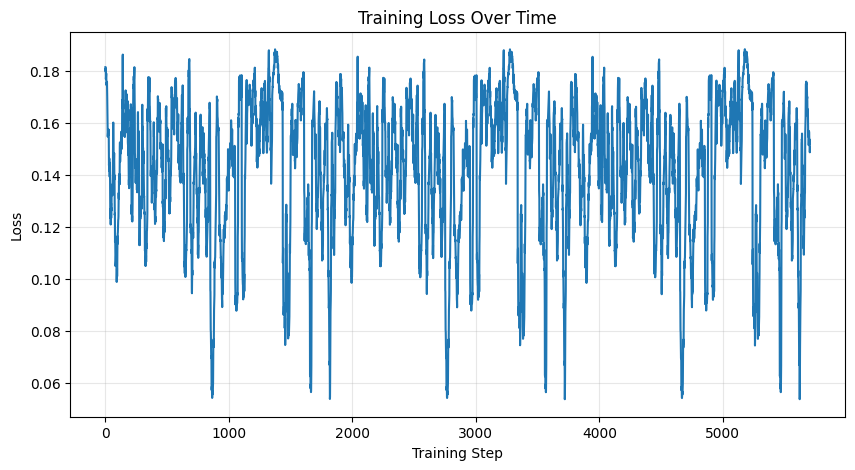


[5/6] Testing model...
Testing on 1229 time steps...


Testing:   0%|          | 0/1229 [00:00<?, ?it/s]Traceback (most recent call last):
  File "C:\Users\archi\AppData\Local\Temp\ipykernel_38152\4144706880.py", line 208, in test_model
    h_t_pos, h_t_neg, signals, _, A_pos, A_neg = model(
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ValueError: too many values to unpack (expected 6)
Testing:   0%|          | 1/1229 [00:00<09:09,  2.24it/s]


!!! Error at 2020-02-13 00:00:00 !!!


Traceback (most recent call last):
  File "C:\Users\archi\AppData\Local\Temp\ipykernel_38152\4144706880.py", line 208, in test_model
    h_t_pos, h_t_neg, signals, _, A_pos, A_neg = model(
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ValueError: too many values to unpack (expected 6)
Testing:   0%|          | 2/1229 [00:00<08:44,  2.34it/s]


!!! Error at 2020-02-14 00:00:00 !!!


...

Epoch 1 - Average Loss: 0.1383


Epoch 2: 100%|██████████| 1983/1983 [08:53<00:00,  3.72it/s]


Epoch 2 - Average Loss: 0.1256


Epoch 3: 100%|██████████| 1983/1983 [09:10<00:00,  3.61it/s]


Epoch 3 - Average Loss: 0.1245


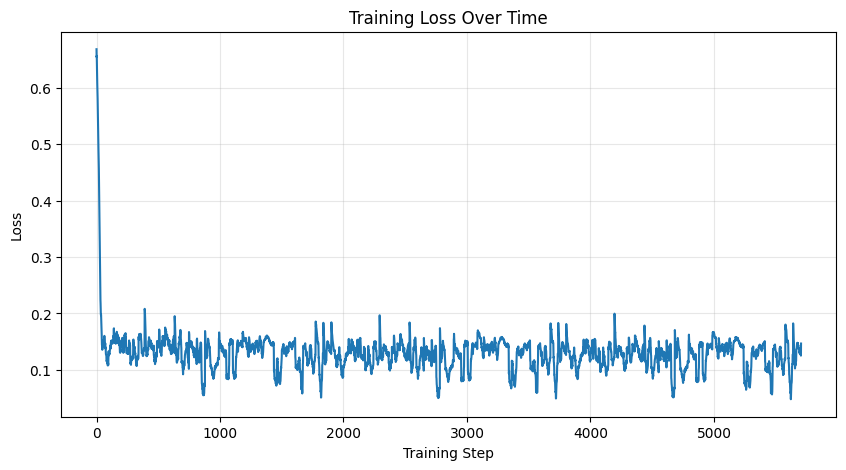


[5/6] Testing model...
Testing on 1229 time steps...


Testing:   0%|          | 0/1229 [00:00<?, ?it/s]Traceback (most recent call last):
  File "C:\Users\archi\AppData\Local\Temp\ipykernel_38152\4144706880.py", line 208, in test_model
    h_t_pos, h_t_neg, signals, _, A_pos, A_neg = model(
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ValueError: too many values to unpack (expected 6)
Testing:   0%|          | 1/1229 [00:00<05:00,  4.09it/s]


!!! Error at 2020-02-13 00:00:00 !!!


Traceback (most recent call last):
  File "C:\Users\archi\AppData\Local\Temp\ipykernel_38152\4144706880.py", line 208, in test_model
    h_t_pos, h_t_neg, signals, _, A_pos, A_neg = model(
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ValueError: too many values to unpack (expected 6)
Testing:   0%|          | 2/1229 [00:00<05:05,  4.02it/s]


!!! Error at 2020-02-14 00:00:00 !!!


...

Epoch 1 - Average Loss: 0.1301


Epoch 2: 100%|██████████| 1983/1983 [08:47<00:00,  3.76it/s]


Epoch 2 - Average Loss: 0.1071


Epoch 3: 100%|██████████| 1983/1983 [08:51<00:00,  3.73it/s]


Epoch 3 - Average Loss: 0.1051


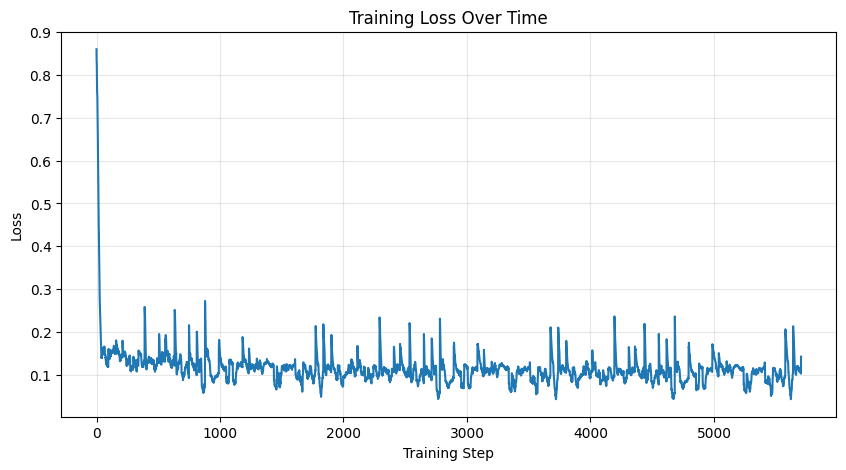


[5/6] Testing model...
Testing on 1229 time steps...


Testing:   0%|          | 0/1229 [00:00<?, ?it/s]Traceback (most recent call last):
  File "C:\Users\archi\AppData\Local\Temp\ipykernel_38152\4144706880.py", line 208, in test_model
    h_t_pos, h_t_neg, signals, _, A_pos, A_neg = model(
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ValueError: too many values to unpack (expected 6)
Testing:   0%|          | 1/1229 [00:00<05:04,  4.04it/s]


!!! Error at 2020-02-13 00:00:00 !!!


Traceback (most recent call last):
  File "C:\Users\archi\AppData\Local\Temp\ipykernel_38152\4144706880.py", line 208, in test_model
    h_t_pos, h_t_neg, signals, _, A_pos, A_neg = model(
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ValueError: too many values to unpack (expected 6)
Testing:   0%|          | 2/1229 [00:00<05:26,  3.75it/s]


!!! Error at 2020-02-14 00:00:00 !!!


...

Epoch 1 - Average Loss: 0.1226


Epoch 2: 100%|██████████| 1983/1983 [09:13<00:00,  3.58it/s]


Epoch 2 - Average Loss: 0.0913


Epoch 3: 100%|██████████| 1983/1983 [08:53<00:00,  3.72it/s]


Epoch 3 - Average Loss: 0.0875


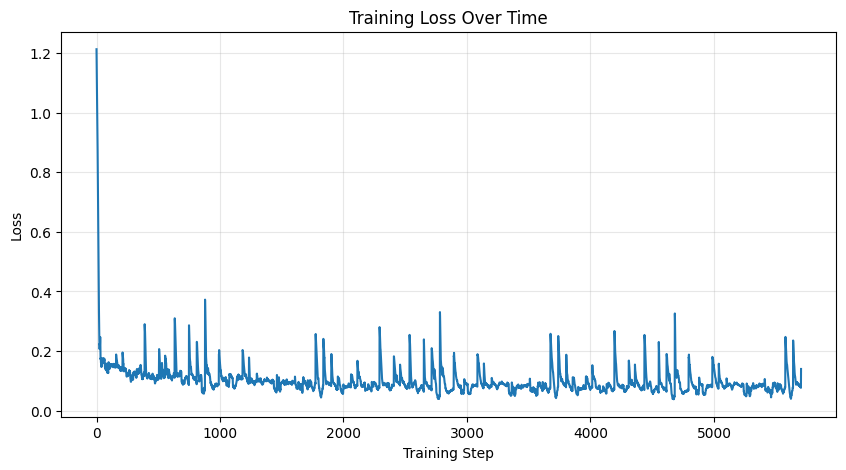


[5/6] Testing model...
Testing on 1229 time steps...


Testing:   0%|          | 0/1229 [00:00<?, ?it/s]Traceback (most recent call last):
  File "C:\Users\archi\AppData\Local\Temp\ipykernel_38152\4144706880.py", line 208, in test_model
    h_t_pos, h_t_neg, signals, _, A_pos, A_neg = model(
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ValueError: too many values to unpack (expected 6)
Testing:   0%|          | 1/1229 [00:00<05:36,  3.65it/s]


!!! Error at 2020-02-13 00:00:00 !!!


Traceback (most recent call last):
  File "C:\Users\archi\AppData\Local\Temp\ipykernel_38152\4144706880.py", line 208, in test_model
    h_t_pos, h_t_neg, signals, _, A_pos, A_neg = model(
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ValueError: too many values to unpack (expected 6)
Testing:   0%|          | 2/1229 [00:00<05:21,  3.82it/s]


!!! Error at 2020-02-14 00:00:00 !!!


...


!!! Error at 2024-12-30 00:00:00 !!!


Traceback (most recent call last):
  File "C:\Users\archi\AppData\Local\Temp\ipykernel_38152\4144706880.py", line 208, in test_model
    h_t_pos, h_t_neg, signals, _, A_pos, A_neg = model(
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ValueError: too many values to unpack (expected 6)
Testing: 100%|██████████| 1229/1229 [06:08<00:00,  3.34it/s]



!!! Error at 2024-12-31 00:00:00 !!!

=== Training with alpha = 0.8 ===
Total parameters: 12,403

[4/6] Training model...
Training on 1983 time steps...


Epoch 1:  90%|████████▉ | 1777/1983 [08:03<00:56,  3.67it/s]


KeyboardInterrupt: 

In [ ]:

def train_model(model, optimizer, returns, sectors, volatility, Market_caps, PE_ratios, Implied_vol, Short_interest,
                 Beta, Operating_margin, Return_on_equity, RSI_momentum, Turnover, 
                train_dates,stock2idx, K=21, save_path='checkpoints'):
    
    device = next(model.parameters()).device
    #stocks = list(returns.columns)          # global universe order
    #stock2idx = {s: i for i, s in enumerate(stocks)}
    N_full = len(stock2idx)
    #stocks = list(returns.columns)
    #N = len(stocks)
    
    # Create edge index once (or you can recreate per timestamp)
    feature_dfs_list = [
    volatility, Market_caps, PE_ratios, Implied_vol, Short_interest, 
    Beta, Operating_margin, Return_on_equity, RSI_momentum, Turnover
    ]

    training_losses = []


    print(f"Training on {len(train_dates)} time steps...")
    
    for epoch in range(3):  # Multiple passes through training data
        epoch_losses = []
        #h_prev = None  # Reset hidden state each epoch
        h_prev_pos_full = torch.zeros(N_full, model.hidden_dim, dtype=torch.float32).to(device)  # Initialize hidden state
        h_prev_neg_full = torch.zeros(N_full, model.hidden_dim, dtype=torch.float32).to(device)  # Initialize hidden state
        for t in tqdm(train_dates, desc=f"Epoch {epoch+1}"):
            try:
                # Get active stocks at time t
                active = get_active_stocks(returns, t, lookback_days=int(K*1.5), feature_dfs=feature_dfs_list, min_obs=K)
                if not active: continue
                returns_t = returns[active]
                volatility_t = volatility[active]
                market_caps_t = Market_caps[active]
                PE_ratios_t = PE_ratios[active]
                Implied_vol_t = Implied_vol[active]
                Short_interest_t = Short_interest[active]
                Beta_t = Beta[active]
                Operating_margin_t = Operating_margin[active]
                Return_on_equity_t = Return_on_equity[active]
                RSI_momentum_t = RSI_momentum[active]
                Turnover_t = Turnover[active]
                stocks_t = active
                N_t = len(stocks_t)
                # 1. Compute PCA embeddings from returns
                node_embeddings, _ = compute_initial_node_embeddings(returns_t, t, K, device=device)
                
                # Extract embeddings for all stocks
                H_list = []
                for stock in stocks_t:
                    if stock in node_embeddings:
                        emb = node_embeddings[stock]
                        if len(emb.shape) > 1 and emb.shape[0] == 1:
                            H_list.append(emb[0])  # Take first embedding
                        else:
                            H_list.append(emb)
                        #H_list.append(node_embeddings[stock][0])  # Take first embedding
                    else:
                        # Default embedding
                        H_list.append(np.zeros(10))  # Assuming L=10
                
                H_t = torch.tensor(np.array(H_list), dtype=torch.float32)
                
                # 2. Compute correlation matrix
                corr_matrix, _ = correlation_matrix(returns_t, t, K)
                corr_t = torch.tensor(corr_matrix, dtype=torch.float32)
                edge_index = create_edge_index(corr_matrix, k_neighbors=15)

                
                # 3. Prepare node features [sector, volatility]
                X_t = prepare_node_features(stocks_t, sectors, volatility_t, market_caps_t, PE_ratios_t, Implied_vol_t, Short_interest_t, Beta_t, Operating_margin_t, Return_on_equity_t, RSI_momentum_t, Turnover_t, t)
                
                #if np.isnan(corr_matrix).any():
                #    print("NaNs in corr:", np.isnan(corr_matrix).sum())

                # 4. Create adjacency matrix for reconstruction (optional)
                A_t_pos, A_t_neg = create_adjacency_from_correlation(corr_matrix, threshold=0.0)
                A_t_pos = A_t_pos.to(device)
                A_t_neg = A_t_neg.to(device)

                active_idx = torch.tensor([stock2idx[s] for s in stocks_t], dtype=torch.long).to(device)
                h_prev_pos = h_prev_pos_full.index_select(0, active_idx) 
                h_prev_neg = h_prev_neg_full.index_select(0, active_idx) 
                # 5. Training step
                # loss, h_prev_pos,h_prev_neg, signals = train_step(
                #     model, optimizer, X_t, H_t, edge_index, 
                #     corr_matrix_tensor, A_t_pos,A_t_neg, h_prev_pos, h_prev_neg
                # )
                model.train()
                optimizer.zero_grad()

                h_t_pos, h_t_neg, signals, loss, A_pos, A_neg, _, _ = model(
                    X_t, H_t, edge_index, corr_t, 
                    h_prev_pos=h_prev_pos, h_prev_neg=h_prev_neg, 
                    A_t_pos=A_t_pos, A_t_neg=A_t_neg
                )
                loss.backward()
                optimizer.step()

                if np.isnan(loss.item()):
                    print(f"!!! NaN Loss detected at time {t} !!!")
                    print("Active stocks:", len(active))
                    print("X_t range:", X_t.min().item(), X_t.max().item())
                    break
                # Update full hidden states
                h_prev_pos_full[active_idx] = h_t_pos.detach()
                h_prev_neg_full[active_idx] = h_t_neg.detach()

                epoch_losses.append(loss.item())
                
            except Exception as e:
                print(f"Error at time {t}: {str(e)}")
                continue
        
        avg_loss = np.mean(epoch_losses)
        training_losses.extend(epoch_losses)
        print(f"Epoch {epoch+1} - Average Loss: {avg_loss:.4f}")
        
        # Save checkpoint
        if save_path is not None:
            # Create directory if it doesn't exist
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_loss,
            }, save_path.replace('.pt', f'_epoch{epoch}.pt'))
    
    return training_losses


def test_model(model, returns, sectors, volatility, Market_caps, PE_ratios, Implied_vol, Short_interest, Beta, 
               Operating_margin, Return_on_equity, RSI_momentum, Turnover, test_dates, stock2idx, K=21):
    device = next(model.parameters()).device
    #stocks = list(returns.columns)
    N_full = len(stock2idx)
    
    h_prev_pos_full = torch.zeros(N_full, model.hidden_dim, device=device)
    h_prev_neg_full = torch.zeros(N_full, model.hidden_dim, device=device)

    feature_dfs_list = [
        volatility, Market_caps, PE_ratios, Implied_vol, Short_interest, 
        Beta, Operating_margin, Return_on_equity, RSI_momentum, Turnover
    ]
    # Storage for results
    all_signals = []
    valid_dates = []
    active_lists = []

    print(f"Testing on {len(test_dates)} time steps...")
    
    for t in tqdm(test_dates, desc="Testing"):
        try:
            # 1. Compute PCA embeddings
            active = get_active_stocks(returns, t, lookback_days=int(K*1.5), feature_dfs=feature_dfs_list, min_obs=K)
            #active_idx = torch.tensor([stock2idx[s] for s in active], dtype=torch.long)
            if not active:
                continue

            returns_t = returns[active]
            volatility_t = volatility[active] 
            market_caps_t = Market_caps[active]
            PE_ratios_t = PE_ratios[active]
            Implied_vol_t = Implied_vol[active]
            Short_interest_t = Short_interest[active]
            Beta_t = Beta[active]
            Operating_margin_t = Operating_margin[active]
            Return_on_equity_t = Return_on_equity[active]
            RSI_momentum_t = RSI_momentum[active]
            Turnover_t = Turnover[active]
            stocks_t    = active
            N_t         = len(stocks_t)

            # Create edge index
            
            node_embeddings, _ = compute_initial_node_embeddings(returns_t, t, K, device=device)
            
            H_list = []
            for stock in stocks_t:
                if stock in node_embeddings.keys():
                    H_list.append(node_embeddings[stock]) 
                else:
                    H_list.append(np.zeros(10))

            H_t = torch.tensor(np.array(H_list), dtype=torch.float32)
            
            # 2. Correlation matrix
            corr_matrix, _ = correlation_matrix(returns_t, t, K)
            corr_t = torch.tensor(corr_matrix, dtype=torch.float32)
            edge_index = create_edge_index(corr_matrix, k_neighbors=15)

            # 3. Node features
            X_t = prepare_node_features(stocks_t, sectors, volatility_t, market_caps_t, PE_ratios_t, Implied_vol_t, Short_interest_t, Beta_t, Operating_margin_t, Return_on_equity_t, RSI_momentum_t, Turnover_t, t)
            A_t_pos, A_t_neg = create_adjacency_from_correlation(corr_matrix, threshold=0.0)
            A_t_pos = A_t_pos.to(device)
            A_t_neg = A_t_neg.to(device)
            # 4. Inference
            # h_prev_pos, h_prev_neg, signals, A_pos, A_neg = inference_step(
            #     model, X_t, H_t, edge_index, corr_matrix_tensor, h_prev_pos, h_prev_neg
            # )
            active_idx = torch.tensor([stock2idx[s] for s in stocks_t], dtype=torch.long).to(device)
            h_prev_pos = h_prev_pos_full.index_select(0, active_idx) 
            h_prev_neg = h_prev_neg_full.index_select(0, active_idx) 

            with torch.no_grad():
                h_t_pos, h_t_neg, signals, _, A_pos, A_neg, _, _ = model(
                    X_t, H_t, edge_index, corr_t,
                    h_prev_pos=h_prev_pos, h_prev_neg=h_prev_neg,
                    A_t_pos=A_t_pos, A_t_neg=A_t_neg
                )

            h_prev_pos_full[active_idx] = h_t_pos.detach()
            h_prev_neg_full[active_idx] = h_t_neg.detach()
            
            all_signals.append(signals.cpu().numpy())
            valid_dates.append(t)
            active_lists.append(stocks_t)
            
        except Exception as e:
            # FIX: Print the ACTUAL error to debug
            print(f"\n!!! Error at {t} !!!")
            traceback.print_exc() 
            continue
        # except Exception as e:
        #     raise RuntimeError(f"Test failed at time {t}") from e
    
    # # Create results DataFrame
    # signals_array = np.array(all_signals)  # (T, N)
    # results = pd.DataFrame(
    #     signals_array,
    #     index=valid_dates,
    #     columns=stocks
    # )
    results = {d: (active_lists[i], all_signals[i]) for i, d in enumerate(valid_dates)}
    return results
    

def main():
    
    # prep data
    print("\n[1/6] Loading data...")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Load prices
    prices = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
    prices.dropna(how='all', inplace=True)
    prices = prices.ffill().bfill()
    prices.columns = prices.columns.droplevel(1)
    
    all_stocks = prices.columns.tolist()
    stock2idx = {s: i for i, s in enumerate(all_stocks)}
    idx2stock = {i: s for s, i in stock2idx.items()}
    N_full = len(all_stocks)

    # Load sectors
    sectors = pd.read_excel('SPX_sectors_data.xlsx', sheet_name='Sectors', 
                            header=0, index_col=0)
    sectors['sector_id'] = sectors['Sector'].astype('category').cat.codes
    

    tickers = prices.columns.get_level_values(0).unique().tolist()
    node_map = {ticker: i for i, ticker in enumerate(tickers)}
    
    # Split data: Train 2007-2009, Test 2019-2021
    train_prices = prices.loc['2012-01-01':'2019-12-31']
    test_prices = prices.loc['2020-01-01':'2024-12-31']

    returns = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
    returns.columns = returns.columns.get_level_values(0)
    returns.dropna(how='all', inplace=True) 
    returns = returns.pct_change().dropna(how='all')
    #returns = returns.ffill().bfill()
    # Compute returns
    # train_returns = train_prices.pct_change().dropna(how='all')
    # test_returns = test_prices.pct_change().dropna(how='all')
    train_returns = returns.loc['2012-01-01':'2019-12-31']
    train_returns = train_returns.ffill().bfill()
    test_returns = returns.loc['2020-01-01':'2024-12-31']
    test_returns = test_returns.ffill().bfill()
    
    # Compute volatility
    train_volatility = train_returns.rolling(window=21).std().dropna(how='all') * np.sqrt(252)
    test_volatility = test_returns.rolling(window=21).std().dropna(how='all') * np.sqrt(252)

    # Helper to load and fix dates
    def load_and_fix_index(filename):
        df = pd.read_csv(filename, index_col=0)
        df.index = pd.to_datetime(df.index, format='%m/%d/%Y') # Fix date format
        df.dropna(how='all', inplace=True)
        df = df.ffill().bfill()
        return df

    # Load Constituent Factors (Tables where Cols = Tickers, Rows = Dates)
    Market_caps = load_and_fix_index('Data/SPX_Constituents_market_cap_2006_2025(in).csv')

    PE_ratios = load_and_fix_index('Data/SPX_Constituents_Calculated_PE_2006_2025(in).csv')

    Implied_vol = load_and_fix_index('Data/SPX_Constituents_Implied_vol_2006_2025(in).csv')

    Beta = load_and_fix_index('Data/SPX_Constituents_Beta_2006_2025(in).csv')
    Operating_margin = load_and_fix_index('Data/SPX_Constituents_Op_Margin_2006_2025(in).csv')   
    Return_on_equity = load_and_fix_index('Data/SPX_Constituents_Ret_On_Equity_2006_2025(in).csv')
    RSI_momentum = load_and_fix_index('Data/SPX_Constituents_RSI_momentum_2006_2025(in).csv')
    Short_interest = load_and_fix_index('Data/SPX_Constituents_Short_Interest_Pct_2006_2025(in).csv')
    Turnover = load_and_fix_index('Data/SPX_Constituents_Turnover_30D_2006_2025(in).csv')

    
    print(f"Training period: {train_returns.index[0]} to {train_returns.index[-1]}")
    print(f"Testing period: {test_returns.index[0]} to {test_returns.index[-1]}")
    print(f"Number of stocks: {len(train_returns.columns)}")
    
    # prep trainig and testing dates
    print("\n[2/6] Preparing training dates...")
    
    K = 21  # Window size
    min_date = train_returns.index[0] + pd.Timedelta(days=K*2)
    train_dates = train_returns.loc[min_date:].index
    
    test_min_date = test_returns.index[0] + pd.Timedelta(days=K*2)
    test_dates = test_returns.loc[test_min_date:].index
    
    print(f"Training time steps: {len(train_dates)}")
    print(f"Testing time steps: {len(test_dates)}")
    
    # initialize model
    print("\n[3/6] Initializing model...")
    
    # Model hyperparameters
    N = len(train_returns.columns)  # Number of stocks
    feature_dim = 11  # [sector_id, volatility, market caps, PE, Implied_vol, ShortInterestPct, Beta, OpMargin, ROE, RSI, Turnover] TODO: try adding more features
    embedding_dim = 10  # PCA embedding dimension (L)
    
    gat_config = {
        'num_layers': 1,
        'heads': [1],  # Single attention head
        'features': [embedding_dim, 8]  # Input: L=10, Output: 8
    }
    alpha_vals = [0.0, 0.2,0.4,0.6,0.8,1.0]
    seed = 42
    for alpha in alpha_vals:
        print(f"\n=== Training with alpha = {alpha} ===")

        torch.manual_seed(seed)
        np.random.seed(seed)

        model = BubbleDetectionModel(
            gat_config=gat_config,
            feature_dim=feature_dim,
            embedding_dim=embedding_dim,
            encoder_channels=[16, 8],  # Spatial encoder: 2 -> 16 -> 8
            hidden_dim=32,  # GRU hidden dimension
            num_diffusion_steps=1,
            alpha = alpha,
            use_structure_recon=True,
            dropout=0.1
        )
        
        optimizer = Adam(model.parameters(), lr=0.001, weight_decay=1e-05)
        
        total_params = sum(p.numel() for p in model.parameters())
        print(f"Total parameters: {total_params:,}")
        
        # training
        print("\n[4/6] Training model...")
        
        # Create output directory
        os.makedirs('outputs', exist_ok=True)
        
        training_losses = train_model(
            model, optimizer, train_returns, sectors, train_volatility, Market_caps, PE_ratios, Implied_vol,
            Short_interest, Beta, Operating_margin, Return_on_equity, RSI_momentum, Turnover,
            train_dates, stock2idx, K=K, save_path='outputs/bubble_model.pt'
        )
        
        # Plot training loss
        plt.figure(figsize=(10, 5))
        plt.plot(training_losses)
        plt.xlabel('Training Step')
        plt.ylabel('Loss')
        plt.title('Training Loss Over Time')
        plt.grid(alpha=0.3)
        plt.savefig('outputs/training_loss.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # testing
        print("\n[5/6] Testing model...")
        
        test_results = test_model(model, test_returns, sectors, test_volatility, Market_caps, PE_ratios, Implied_vol, Short_interest, Beta, 
                Operating_margin, Return_on_equity, RSI_momentum, Turnover, test_dates, stock2idx, K=21)
        
        #print(f"Average bubble signal: {test_results.mean().mean():.4f}")
        #print(f"Max bubble signal: {test_results.max().max():.4f}")

        # Save results
        pd.to_pickle(test_results, f"outputs/test_results_test_1Apr_alpha_{alpha}.pkl")
        pd.to_pickle(test_prices, f"outputs/test_prices_test_1Apr_alpha_{alpha}.pkl")
    return test_results, test_prices

if __name__ == "__main__":
    test_results, test_prices = main()




[Accuracy Evaluation] Calculating Predictive Power...
------------------------------------------------------------
PREDICTIVE ACCURACY (Forward Window: 5 days, Crash Threshold: -30.0%)
------------------------------------------------------------
1. AUC-ROC Score:      0.7810  (0.5 = Random, >0.6 = Good, >0.7 = Excellent)
2. Info Coefficient:   0.0249   (Correlation with actual crashes)
3. Precision (Top 10%):0.20% (Of highest signals, this % actually crashed)
4. Baseline Crash Rate:0.05% (Random probability of a crash)
5. Model Lift:         4.01x    (Model is 4.0 times better than random guessing)
------------------------------------------------------------


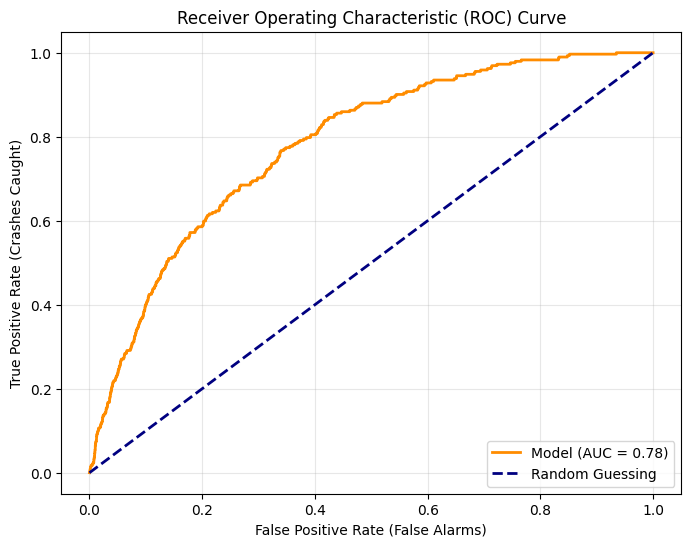


Sample Successful 'Bubble Bursts' Predicted:
      Date          Stock   Signal  Return_Next_Month
2020-03-09   BA UN Equity 1.000000          -0.429458
2020-03-09 NCLH UN Equity 0.726823          -0.447754
2020-03-10   BA UN Equity 1.000000          -0.438942
2020-03-10 NCLH UN Equity 0.715874          -0.466341
2020-03-11   BA UN Equity 1.000000          -0.314523
2020-03-13   BA UN Equity 1.000000          -0.401351
2020-03-13  MGM UN Equity 0.858054          -0.537565
2024-07-29 MRNA UW Equity 0.963140          -0.314480


In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, precision_score
import matplotlib.pyplot as plt

def evaluate_predictive_power(test_results, prices, forward_window=22, crash_threshold=-0.10):
    """
    Calculates accuracy by checking if high signals actually lead to price drops.
    
    Args:
        forward_window: Days to look ahead (e.g., 22 days = 1 month)
        crash_threshold: Return threshold to define a 'Real Crash' (e.g., -0.10 means -10% drop)
    """
    print("\n[Accuracy Evaluation] Calculating Predictive Power...")
    
    y_true = []   # 1 if stock actually crashed, 0 otherwise
    y_scores = [] # Your anomaly signal
    
    # List to track specific successful predictions for debugging
    successful_calls = []
    
    sorted_dates = sorted(list(test_results.keys()))
    
    # We stop early so we have enough data for the forward window
    valid_dates = [d for d in sorted_dates if d <= prices.index[-1] - pd.Timedelta(days=forward_window*1.5)]
    
    for t in valid_dates:
        stocks, signals = test_results[t]
        
        if isinstance(signals, torch.Tensor):
            signals = signals.cpu().numpy()
        signals = signals.flatten()
        
        # Calculate Forward Returns for these stocks
        # Get price at t
        p_t = prices.loc[t, stocks]
        
        # Get price at t + window
        # Find nearest valid date in future
        future_idx = prices.index.searchsorted(t + pd.Timedelta(days=forward_window))
        if future_idx >= len(prices): continue
        future_date = prices.index[future_idx]
        p_future = prices.loc[future_date, stocks]
        
        # Return calculation
        fwd_returns = (p_future - p_t) / p_t
        
        # Define Ground Truth: Did it crash?
        # If return < -10%, it is a "True Anomaly" (Class 1)
        is_crash = (fwd_returns < crash_threshold).astype(int)
        
        y_true.extend(is_crash.values)
        y_scores.extend(signals)
        
        # Track Top Predictions
        # Combine into dataframe
        df_eval = pd.DataFrame({'Stock': stocks, 'Signal': signals, 'Return': fwd_returns, 'Crash': is_crash})
        top_picks = df_eval.sort_values('Signal', ascending=False).head(5)
        
        for _, row in top_picks.iterrows():
            if row['Crash'] == 1:
                successful_calls.append({
                    'Date': t.strftime('%Y-%m-%d'),
                    'Stock': row['Stock'],
                    'Signal': row['Signal'],
                    'Return_Next_Month': row['Return']
                })

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)
    
    # --- METRIC 1: AUC-ROC ---
    # Can the model distinguish between a crash and normal price action?
    auc = roc_auc_score(y_true, y_scores)
    
    # --- METRIC 2: Information Coefficient (IC) ---
    # Correlation between Signal and Crash Probability
    # Ideally Positive (Higher Signal = Higher Probability of Crash)
    ic = np.corrcoef(y_scores, y_true)[0, 1]
    
    # --- METRIC 3: Precision @ Top 10% ---
    # If we take the top 10% highest signals, what % were actually crashes?
    threshold_top_10 = np.percentile(y_scores, 90)
    high_signal_indices = y_scores > threshold_top_10
    
    precision_top_10 = np.mean(y_true[high_signal_indices]) # % of high signals that were crashes
    baseline_crash_rate = np.mean(y_true) # % of ALL stocks that crashed
    
    # Lift: How much better is the model than random chance?
    lift = precision_top_10 / baseline_crash_rate if baseline_crash_rate > 0 else 0
    
    print("-" * 60)
    print(f"PREDICTIVE ACCURACY (Forward Window: {forward_window} days, Crash Threshold: {crash_threshold*100}%)")
    print("-" * 60)
    print(f"1. AUC-ROC Score:      {auc:.4f}  (0.5 = Random, >0.6 = Good, >0.7 = Excellent)")
    print(f"2. Info Coefficient:   {ic:.4f}   (Correlation with actual crashes)")
    print(f"3. Precision (Top 10%):{precision_top_10:.2%} (Of highest signals, this % actually crashed)")
    print(f"4. Baseline Crash Rate:{baseline_crash_rate:.2%} (Random probability of a crash)")
    print(f"5. Model Lift:         {lift:.2f}x    (Model is {lift:.1f} times better than random guessing)")
    print("-" * 60)
    
    # --- Visualization: ROC Curve ---
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"Model (AUC = {auc:.2f})", color='darkorange', lw=2)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')
    plt.xlabel('False Positive Rate (False Alarms)')
    plt.ylabel('True Positive Rate (Crashes Caught)')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    
    print("\nSample Successful 'Bubble Bursts' Predicted:")
    print(pd.DataFrame(successful_calls).head(10).to_string(index=False))

# ==============================================================================
# EXECUTION
# ==============================================================================

test_results = pd.read_pickle("outputs/test_results_test_run31Mar.pkl")
test_prices = pd.read_pickle("outputs/test_prices_test_run31Mar.pkl")
    # Evaluate 1-Month Forward Accuracy looking for -15% Drops
evaluate_predictive_power(test_results, test_prices, forward_window=5, crash_threshold=-0.30)


[5] Visualizing Average Anomaly Signal (Regression Baseline)...


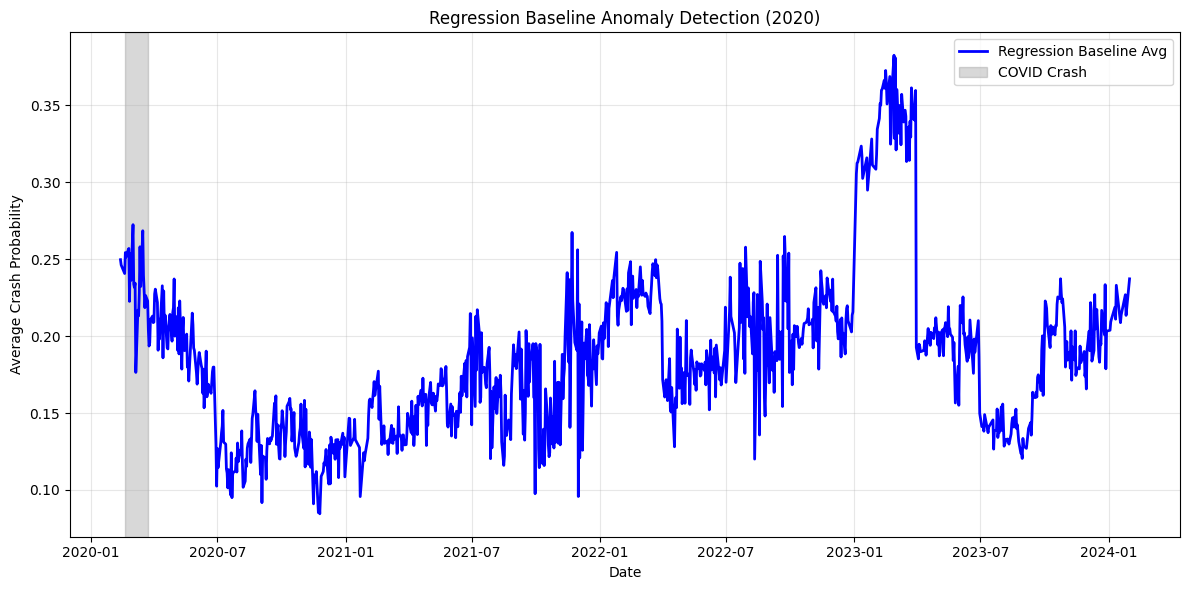

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("[5] Visualizing Average Anomaly Signal (Regression Baseline)...")

# 1. Convert the dictionary results into a pandas Series of average scores
# reg_results structure: {date: (active_stocks_list, probabilities_array)}
date_map = {}

for date, (stocks, probs) in test_results.items():
    # We take the mean of the probabilities for that specific day
    date_map[date] = np.mean(probs)

# Create a Series sorted by date
avg_signals = pd.Series(date_map).sort_index()

# 2. Filter for 2020
try:
    # Slice the series for the year 2020
    avg_signals_2020 = avg_signals.loc['2020-01-01':'2024-01-31']
except KeyError:
    print("Warning: Date range not found in data.")
    avg_signals_2020 = pd.Series()

# 3. Plot
if not avg_signals_2020.empty:
    plt.figure(figsize=(12, 6))

    # Plot directly using the index (dates) and values
    plt.plot(avg_signals_2020.index, avg_signals_2020.values, color='blue', linewidth=2, label='Regression Baseline Avg')

    # Highlight COVID Crash
    plt.axvspan(pd.Timestamp('2020-02-20'), pd.Timestamp('2020-03-23'), 
                color='grey', alpha=0.3, label='COVID Crash')

    plt.title("Regression Baseline Anomaly Detection (2020)")
    plt.ylabel("Average Crash Probability")
    plt.xlabel("Date")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No data found for 2020.")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
import torch


def evaluate_once(
        test_results,
        prices,
        forward_window,
        crash_threshold
):

    y_true = []
    y_scores = []

    sorted_dates = sorted(test_results.keys())

    valid_dates = [
        d for d in sorted_dates
        if d <= prices.index[-1] - pd.Timedelta(days=forward_window)
    ]

    for t in valid_dates:

        stocks, signals = test_results[t]

        if isinstance(signals, torch.Tensor):
            signals = signals.cpu().numpy()

        signals = signals.flatten()

        available = [s for s in stocks if s in prices.columns]

        if len(available) == 0:
            continue

        mask = [i for i,s in enumerate(stocks) if s in available]

        signals = signals[mask]

        p_t = prices.loc[t, available]

        future_idx = prices.index.searchsorted(
            t + pd.Timedelta(days=forward_window)
        )

        if future_idx >= len(prices):
            continue

        future_date = prices.index[future_idx]

        p_future = prices.loc[future_date, available]

        fwd_returns = (p_future - p_t) / p_t

        crash = (fwd_returns < crash_threshold).astype(int)

        y_true.extend(crash.values)

        y_scores.extend(signals)

    if len(y_true) == 0:
        return None

    y_true = np.array(y_true)
    y_scores = np.array(y_scores)

    auc = roc_auc_score(y_true, y_scores)

    baseline = y_true.mean()

    precision = y_true[y_scores > np.percentile(y_scores, 90)].mean()

    lift = precision / baseline if baseline > 0 else np.nan

    return auc, lift, baseline

def grid_search(
        test_results,
        prices,
        forward_windows,
        crash_thresholds
):

    rows = []

    for fw in forward_windows:

        for ct in crash_thresholds:

            result = evaluate_once(
                test_results,
                prices,
                fw,
                ct
            )

            if result is None:
                continue

            auc, lift, baseline = result

            rows.append({

                "ForwardWindow": fw,

                "CrashThreshold": ct,

                "AUC": auc,

                "Lift": lift,

                "Baseline": baseline

            })

            print(
                f"FW={fw:3d} "
                f"CT={ct:6.2f} "
                f"AUC={auc:.3f} "
                f"Lift={lift:.2f}"
            )

    return pd.DataFrame(rows)


In [ ]:
forward_windows = [5,10,22,44,66,120]

crash_thresholds = [-0.05,-0.10,-0.15,-0.20,-0.30]

test_results = pd.read_pickle("outputs/test_results_test_run31Mar.pkl")

test_prices = pd.read_pickle("outputs/test_prices_test_run31Mar.pkl")

df_results = grid_search(

    test_results,

    test_prices,

    forward_windows,

    crash_thresholds

)
# for test_results_test : FW=  5 CT= -0.30 AUC=0.785 Lift=4.45 testing from 2020-2024


FW=  5 CT= -0.05 AUC=0.541 Lift=1.43
FW=  5 CT= -0.10 AUC=0.611 Lift=2.06
FW=  5 CT= -0.15 AUC=0.669 Lift=2.62
FW=  5 CT= -0.20 AUC=0.691 Lift=2.75
FW=  5 CT= -0.30 AUC=0.781 Lift=4.01
FW= 10 CT= -0.05 AUC=0.529 Lift=1.26
FW= 10 CT= -0.10 AUC=0.585 Lift=1.82
FW= 10 CT= -0.15 AUC=0.639 Lift=2.33
FW= 10 CT= -0.20 AUC=0.650 Lift=2.51
FW= 10 CT= -0.30 AUC=0.673 Lift=2.63
FW= 22 CT= -0.05 AUC=0.531 Lift=1.22
FW= 22 CT= -0.10 AUC=0.566 Lift=1.63
FW= 22 CT= -0.15 AUC=0.610 Lift=2.20
FW= 22 CT= -0.20 AUC=0.634 Lift=2.59
FW= 22 CT= -0.30 AUC=0.607 Lift=2.41
FW= 44 CT= -0.05 AUC=0.527 Lift=1.18
FW= 44 CT= -0.10 AUC=0.553 Lift=1.45
FW= 44 CT= -0.15 AUC=0.586 Lift=1.85
FW= 44 CT= -0.20 AUC=0.635 Lift=2.53
FW= 44 CT= -0.30 AUC=0.678 Lift=3.30
FW= 66 CT= -0.05 AUC=0.532 Lift=1.18
FW= 66 CT= -0.10 AUC=0.549 Lift=1.38
FW= 66 CT= -0.15 AUC=0.574 Lift=1.71
FW= 66 CT= -0.20 AUC=0.616 Lift=2.16
FW= 66 CT= -0.30 AUC=0.694 Lift=3.39
FW=120 CT= -0.05 AUC=0.545 Lift=1.14
FW=120 CT= -0.10 AUC=0.558 Lift=1.25
F

In [ ]:
import numpy as np
import scipy
from scipy import stats
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler
import pandas as pd
import torch

test_results = pd.read_pickle("outputs/test_results_test_fix3Mar1.pkl")

def compute_graph_features(signals, A_pos, A_neg, returns_t):
    """
    Compresses per-stock signals + graph structure into a single 
    feature vector describing the market state at time t.
    """
    signals = signals.flatten()
    N = len(signals)
    
    # --- Signal distribution features ---
    mean_signal = np.mean(signals)
    std_signal = np.std(signals)
    skew_signal = scipy.stats.skew(signals)
    # Fraction of stocks with anomaly signal above 80th percentile
    frac_high = np.mean(signals > np.percentile(signals, 80))
    # This is always 0.2 by definition within a single snapshot.
    # More useful: track a GLOBAL threshold from training.
    # But for HMM, the raw percentile values (90th, 95th) work better:
    p90_signal = np.percentile(signals, 90)
    p10_signal = np.percentile(signals, 10)
    signal_range = p90_signal - p10_signal  # dispersion

    # --- Graph structure features (from A_pos) ---
    # Density: how connected is the positive correlation network?
    pos_density = (A_pos > 0).sum().item() / (N * (N - 1))
    neg_density = (A_neg > 0).sum().item() / (N * (N - 1))
    
    # Mean edge weight: how STRONG are the correlations?
    pos_mean_weight = A_pos[A_pos > 0].mean().item() if (A_pos > 0).any() else 0
    neg_mean_weight = A_neg[A_neg > 0].mean().item() if (A_neg > 0).any() else 0
    
    # Spectral gap of A_pos (difference between 1st and 2nd eigenvalue)
    # Large spectral gap = one dominant factor driving everything (crisis signature)
    eigenvalues = np.linalg.eigvalsh(A_pos.numpy() if hasattr(A_pos, 'numpy') else A_pos)
    eigenvalues = np.sort(eigenvalues)[::-1]
    spectral_gap = eigenvalues[0] - eigenvalues[1] if len(eigenvalues) > 1 else 0
    # Ratio is more stable than difference:
    spectral_ratio = eigenvalues[0] / (eigenvalues[1] + 1e-8)
    
    # --- Cross features (signal × structure) ---
    # Are high-signal stocks clustered together in the network?
    high_mask = signals > np.percentile(signals, 75)
    if high_mask.sum() > 1:
        # Sub-graph density among high-signal stocks
        high_idx = np.where(high_mask)[0]
        A_pos_np = A_pos.numpy() if hasattr(A_pos, 'numpy') else A_pos
        subgraph = A_pos_np[np.ix_(high_idx, high_idx)]
        high_stock_connectivity = subgraph.mean()
    else:
        high_stock_connectivity = 0.0
    
    # --- Market return features ---
    avg_return = np.mean(returns_t) if returns_t is not None else 0
    return_dispersion = np.std(returns_t) if returns_t is not None else 0

    return np.array([
        mean_signal, std_signal, skew_signal, signal_range,
        p90_signal, p10_signal,
        pos_density, neg_density,
        pos_mean_weight, neg_mean_weight,
        spectral_gap, spectral_ratio,
        high_stock_connectivity,
        avg_return, return_dispersion
    ])

graph_features = []
dates = []

returns = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
returns.columns = returns.columns.get_level_values(0)
returns.dropna(how='all', inplace=True) 
returns = returns.pct_change().dropna(how='all')

returns = returns.loc['2020-01-01':'2024-12-31']
returns = returns.ffill().bfill()

for t in sorted(test_results.keys()):
    stocks, signals = test_results[t]
    if isinstance(signals, torch.Tensor):
        signals = signals.cpu().numpy()
    
    # You need A_pos, A_neg for this date too
    # Either store them during test_model, or recompute:
    corr_mat, _ = correlation_matrix(returns[stocks], t, K=21)
    A_t_pos, A_t_neg = create_adjacency_from_correlation(corr_mat)
    
    # Get returns at t for the active stocks
    ret_t = returns.loc[t, stocks].values if t in returns.index else None
    
    feat = compute_graph_features(signals, A_t_pos, A_t_neg, ret_t)
    graph_features.append(feat)
    dates.append(t)

X_regime = np.array(graph_features)  # shape: (T, 15)



# Normalize features (HMMs are sensitive to scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_regime)

# Fit HMM with 3 states
hmm = GaussianHMM(
    n_components=3,        # 3 regimes: bull, bear, transition
    covariance_type="full", # full captures correlations between features
    n_iter=200,
    random_state=42,
    tol=0.01
)
hmm.fit(X_scaled)

# Predict most likely regime at each time step
regime_labels = hmm.predict(X_scaled)

# Get regime probabilities (more useful than hard labels)
regime_probs = hmm.predict_proba(X_scaled)  # (T, 3)

import pandas as pd

feature_names = [
    'mean_signal', 'std_signal', 'skew_signal', 'signal_range',
    'p90_signal', 'p10_signal',
    'pos_density', 'neg_density',
    'pos_mean_weight', 'neg_mean_weight',
    'spectral_gap', 'spectral_ratio',
    'high_stock_connectivity',
    'avg_return', 'return_dispersion'
]

for state in range(3):
    mask = regime_labels == state
    print(f"\n--- State {state} ({mask.sum()} days) ---")
    state_means = X_regime[mask].mean(axis=0)
    for name, val in zip(feature_names, state_means):
        print(f"  {name:30s}: {val:.4f}")


--- State 0 (395 days) ---
  mean_signal                   : 0.1529
  std_signal                    : 0.0926
  skew_signal                   : 4.5677
  signal_range                  : 0.1361
  p90_signal                    : 0.2268
  p10_signal                    : 0.0908
  pos_density                   : 0.7583
  neg_density                   : 0.1624
  pos_mean_weight               : 0.3578
  neg_mean_weight               : 0.1544
  spectral_gap                  : 107.0676
  spectral_ratio                : 3.2413
  high_stock_connectivity       : 0.2341
  avg_return                    : 0.0012
  return_dispersion             : 0.0181

--- State 1 (215 days) ---
  mean_signal                   : 0.2016
  std_signal                    : 0.1150
  skew_signal                   : 2.9933
  signal_range                  : 0.2077
  p90_signal                    : 0.3145
  p10_signal                    : 0.1068
  pos_density                   : 0.8995
  neg_density                   : 0.0240

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# Identify which state is which by avg_return
state_avg_returns = []
for s in range(3):
    mask = regime_labels == s
    state_avg_returns.append(X_regime[mask, -2].mean())  # avg_return is index -2

crisis_state = np.argmin(state_avg_returns)   # most negative return
bull_state = np.argmax(state_avg_returns)      # most positive return
neutral_state = [s for s in range(3) if s not in [crisis_state, bull_state]][0]
prices = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
prices.dropna(how='all', inplace=True)
prices = prices.ffill().bfill()
prices.columns = prices.columns.droplevel(1)
# Get S&P 500 index prices for the same dates
spx_prices = prices.loc[dates].mean(axis=1)  # or use an actual SPX index if you have one

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1, 1]})

# Panel 1: S&P 500 with regime shading
ax1 = axes[0]
ax1.plot(dates, spx_prices.values, color='black', linewidth=1)

# Shade background by regime
for i in range(len(dates) - 1):
    r = regime_labels[i]
    if r == crisis_state:
        ax1.axvspan(dates[i], dates[i+1], alpha=0.3, color='red')
    elif r == bull_state:
        ax1.axvspan(dates[i], dates[i+1], alpha=0.15, color='green')
    else:
        ax1.axvspan(dates[i], dates[i+1], alpha=0.15, color='orange')

ax1.set_ylabel('S&P 500 (avg price)', fontsize=12)
ax1.set_title('HMM Regime Detection using GAT Graph Features', fontsize=14, fontweight='bold')

# Legend patches
from matplotlib.patches import Patch
ax1.legend(handles=[
    Patch(facecolor='green', alpha=0.3, label=f'State {bull_state}: Calm Bull'),
    Patch(facecolor='orange', alpha=0.3, label=f'State {neutral_state}: Neutral / Late Cycle'),
    Patch(facecolor='red', alpha=0.3, label=f'State {crisis_state}: Crisis / Stress'),
], loc='upper left')
ax1.grid(alpha=0.2)

# Panel 2: Regime probabilities
ax2 = axes[1]
ax2.fill_between(dates, regime_probs[:, crisis_state], alpha=0.5, color='red', label='P(Crisis)')
ax2.fill_between(dates, regime_probs[:, neutral_state], alpha=0.4, color='orange', label='P(Neutral)')
ax2.fill_between(dates, regime_probs[:, bull_state], alpha=0.3, color='green', label='P(Bull)')
ax2.axhline(0.5, linestyle='--', color='gray', alpha=0.5)
ax2.set_ylabel('Regime Probability', fontsize=12)
ax2.legend(loc='upper right')
ax2.set_ylim(0, 1)
ax2.grid(alpha=0.2)

# Panel 3: Key graph features that distinguish regimes
ax3 = axes[2]
ax3.plot(dates, X_regime[:, feature_names.index('spectral_ratio')], 
         color='purple', linewidth=1, label='Spectral Ratio')
ax3_twin = ax3.twinx()
ax3_twin.plot(dates, X_regime[:, feature_names.index('pos_density')], 
              color='blue', linewidth=1, alpha=0.7, label='Pos Density')
ax3.set_ylabel('Spectral Ratio', fontsize=12, color='purple')
ax3_twin.set_ylabel('Positive Density', fontsize=12, color='blue')
ax3.set_xlabel('Date', fontsize=12)
ax3.legend(loc='upper left')
ax3_twin.legend(loc='upper right')
ax3.grid(alpha=0.2)

ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('regime_detection_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

KeyboardInterrupt: 

In [ ]:

def main():
    
    # prep data
    print("\n[1/6] Loading data...")
    device = torch.device("cpu")
    
    # Load prices
    prices = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
    prices.dropna(how='all', inplace=True)
    prices = prices.ffill().bfill()
    prices.columns = prices.columns.droplevel(1)
    
    all_stocks = prices.columns.tolist()
    stock2idx = {s: i for i, s in enumerate(all_stocks)}
    idx2stock = {i: s for s, i in stock2idx.items()}
    N_full = len(all_stocks)

    # Load sectors
    sectors = pd.read_excel('SPX_sectors_data.xlsx', sheet_name='Sectors', 
                            header=0, index_col=0)
    sectors['sector_id'] = sectors['Sector'].astype('category').cat.codes
    

    tickers = prices.columns.get_level_values(0).unique().tolist()
    node_map = {ticker: i for i, ticker in enumerate(tickers)}
    
    # Split data: Train 2007-2009, Test 2019-2021
    train_prices = prices.loc['2012-01-01':'2019-12-31']
    test_prices = prices.loc['2007-01-01':'2011-12-31']

    returns = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
    returns.columns = returns.columns.get_level_values(0)
    returns.dropna(how='all', inplace=True) 
    returns = returns.pct_change().dropna(how='all')
    returns = returns.ffill().bfill()
    # Compute returns
    # train_returns = train_prices.pct_change().dropna(how='all')
    # test_returns = test_prices.pct_change().dropna(how='all')
    train_returns = returns.loc['2012-01-01':'2019-12-31']
    test_returns = returns.loc['2007-01-01':'2011-12-31']
    
    # Compute volatility
    train_volatility = train_returns.rolling(window=21).std().dropna(how='all') * np.sqrt(252)
    test_volatility = test_returns.rolling(window=21).std().dropna(how='all') * np.sqrt(252)

    # Helper to load and fix dates
    def load_and_fix_index(filename):
        df = pd.read_csv(filename, index_col=0)
        df.index = pd.to_datetime(df.index, format='%m/%d/%Y') # Fix date format
        df.dropna(how='all', inplace=True)
        df = df.ffill().bfill()
        return df

    # Load Constituent Factors (Tables where Cols = Tickers, Rows = Dates)
    Market_caps = load_and_fix_index('Data/SPX_Constituents_market_cap_2006_2025(in).csv')

    PE_ratios = load_and_fix_index('Data/SPX_Constituents_Calculated_PE_2006_2025(in).csv')

    Implied_vol = load_and_fix_index('Data/SPX_Constituents_Implied_vol_2006_2025(in).csv')

    Beta = load_and_fix_index('Data/SPX_Constituents_Beta_2006_2025(in).csv')
    Operating_margin = load_and_fix_index('Data/SPX_Constituents_Op_Margin_2006_2025(in).csv')   
    Return_on_equity = load_and_fix_index('Data/SPX_Constituents_Ret_On_Equity_2006_2025(in).csv')
    RSI_momentum = load_and_fix_index('Data/SPX_Constituents_RSI_momentum_2006_2025(in).csv')
    Short_interest = load_and_fix_index('Data/SPX_Constituents_Short_Interest_Pct_2006_2025(in).csv')
    Turnover = load_and_fix_index('Data/SPX_Constituents_Turnover_30D_2006_2025(in).csv')

    
    print(f"Training period: {train_returns.index[0]} to {train_returns.index[-1]}")
    print(f"Testing period: {test_returns.index[0]} to {test_returns.index[-1]}")
    print(f"Number of stocks: {len(train_returns.columns)}")
    
    # prep trainig and testing dates
    print("\n[2/6] Preparing training dates...")
    
    K = 21  # Window size
    min_date = train_returns.index[0] + pd.Timedelta(days=K*2)
    train_dates = train_returns.loc[min_date:].index
    
    test_min_date = test_returns.index[0] + pd.Timedelta(days=K*2)
    test_dates = test_returns.loc[test_min_date:].index
    
    print(f"Training time steps: {len(train_dates)}")
    print(f"Testing time steps: {len(test_dates)}")
    
    # initialize model
    print("\n[3/6] Initializing model...")
    
    # Model hyperparameters
    N = len(train_returns.columns)  # Number of stocks
    feature_dim = 11  # [sector_id, volatility, market caps, PE, Implied_vol, ShortInterestPct, Beta, OpMargin, ROE, RSI, Turnover] TODO: try adding more features
    embedding_dim = 10  # PCA embedding dimension (L)
    
    gat_config = {
        'num_layers': 1,
        'heads': [1],  # Single attention head
        'features': [embedding_dim, 8]  # Input: L=10, Output: 8
    }
    
    model = BubbleDetectionModel(
        gat_config=gat_config,
        feature_dim=feature_dim,
        embedding_dim=embedding_dim,
        encoder_channels=[16, 8],  # Spatial encoder: 2 -> 16 -> 8
        hidden_dim=32,  # GRU hidden dimension
        num_diffusion_steps=1,
        use_structure_recon=True,
        dropout=0.1
    )
    
    optimizer = Adam(model.parameters(), lr=0.001, weight_decay=1e-05)
    
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params:,}")
    
    # training
    print("\n[4/6] Training model...")
    
    # Create output directory
    os.makedirs('outputs', exist_ok=True)
    
    training_losses = train_model(
        model, optimizer, train_returns, sectors, train_volatility, Market_caps, PE_ratios, Implied_vol,
        Short_interest, Beta, Operating_margin, Return_on_equity, RSI_momentum, Turnover,
        train_dates, stock2idx, K=K, save_path='outputs/bubble_model.pt'
    )
    
    # Plot training loss
    plt.figure(figsize=(10, 5))
    plt.plot(training_losses)
    plt.xlabel('Training Step')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Time')
    plt.grid(alpha=0.3)
    plt.savefig('outputs/training_loss.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # testing
    print("\n[5/6] Testing model...")
    
    test_results = test_model(model, test_returns, sectors, test_volatility, Market_caps, PE_ratios, Implied_vol, Short_interest, Beta, 
               Operating_margin, Return_on_equity, RSI_momentum, Turnover, test_dates, stock2idx, K=21)
    
    #print(f"Average bubble signal: {test_results.mean().mean():.4f}")
    #print(f"Max bubble signal: {test_results.max().max():.4f}")

    # Save results
    pd.to_pickle(test_results, "outputs/test_results_test_2007to2011.pkl")
    pd.to_pickle(test_prices, "outputs/test_prices_test_2007to2011.pkl")
    return test_results, test_prices

if __name__ == "__main__":
    test_results, test_prices = main()



[5/6] Testing model...


NameError: name 'model' is not defined

In [ ]:
feature_dim = 11  # [sector_id, volatility, market caps, PE, Implied_vol, ShortInterestPct, Beta, OpMargin, ROE, RSI, Turnover] TODO: try adding more features
embedding_dim = 10  # PCA embedding dimension (L)

gat_config = {
    'num_layers': 1,
    'heads': [1],  # Single attention head
    'features': [embedding_dim, 8]  # Input: L=10, Output: 8
}
model = BubbleDetectionModel(
    gat_config=gat_config,
    feature_dim=feature_dim,
    embedding_dim=embedding_dim,
    encoder_channels=[16, 8],
    hidden_dim=32,
    num_diffusion_steps=1,
    use_structure_recon=True,
    dropout=0.1
)

checkpoint = torch.load("outputs/bubble_model_epoch2.pt", map_location="cpu", weights_only=False)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

returns = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
returns.columns = returns.columns.get_level_values(0)
returns.dropna(how='all', inplace=True) 
returns = returns.pct_change().dropna(how='all')
returns = returns.ffill().bfill()

new_test_returns = returns.loc['2006-01-01':'2011-12-31']
new_test_volatility = new_test_returns.rolling(window=21).std() * np.sqrt(252)
K=21
new_min_date = new_test_returns.index[0] + pd.Timedelta(days=K*2)
new_test_dates = new_test_returns.loc[new_min_date:].index

def load_and_fix_index(filename):
        df = pd.read_csv(filename, index_col=0)
        df.index = pd.to_datetime(df.index, format='%m/%d/%Y') # Fix date format
        df.dropna(how='all', inplace=True)
        df = df.ffill().bfill()
        return df

    # Load Constituent Factors (Tables where Cols = Tickers, Rows = Dates)
Market_caps = load_and_fix_index('Data/SPX_Constituents_market_cap_2006_2025(in).csv')

PE_ratios = load_and_fix_index('Data/SPX_Constituents_Calculated_PE_2006_2025(in).csv')

Implied_vol = load_and_fix_index('Data/SPX_Constituents_Implied_vol_2006_2025(in).csv')

Beta = load_and_fix_index('Data/SPX_Constituents_Beta_2006_2025(in).csv')
Operating_margin = load_and_fix_index('Data/SPX_Constituents_Op_Margin_2006_2025(in).csv')   
Return_on_equity = load_and_fix_index('Data/SPX_Constituents_Ret_On_Equity_2006_2025(in).csv')
RSI_momentum = load_and_fix_index('Data/SPX_Constituents_RSI_momentum_2006_2025(in).csv')
Short_interest = load_and_fix_index('Data/SPX_Constituents_Short_Interest_Pct_2006_2025(in).csv')
Turnover = load_and_fix_index('Data/SPX_Constituents_Turnover_30D_2006_2025(in).csv')

prices = pd.read_excel('SPX_sectors_data.xlsx', header=[0,1], index_col=0)
prices.dropna(how='all', inplace=True)
prices = prices.ffill().bfill()
prices.columns = prices.columns.droplevel(1)

all_stocks = prices.columns.tolist()
stock2idx = {s: i for i, s in enumerate(all_stocks)}
idx2stock = {i: s for s, i in stock2idx.items()}
N_full = len(all_stocks)

# Load sectors
sectors = pd.read_excel('SPX_sectors_data.xlsx', sheet_name='Sectors', 
                        header=0, index_col=0)
sectors['sector_id'] = sectors['Sector'].astype('category').cat.codes

new_results = test_model(
    model,
    new_test_returns,
    sectors,
    new_test_volatility,
    Market_caps,
    PE_ratios,
    Implied_vol,
    Short_interest,
    Beta,
    Operating_margin,
    Return_on_equity,
    RSI_momentum,
    Turnover,
    new_test_dates,
    stock2idx,
    K=21
)


Testing on 1482 time steps...


Testing: 100%|██████████| 1482/1482 [11:21<00:00,  2.17it/s]


In [ ]:
forward_windows = [5,10,22,44,66,120]

crash_thresholds = [-0.05,-0.10,-0.15,-0.20,-0.30]

test_prices = prices.loc['2006-01-01':'2011-12-31']

df_results = grid_search(

    new_results,

    test_prices,

    forward_windows,

    crash_thresholds

)
# for test_results_test : FW=  5 CT= -0.30 AUC=0.848 Lift=5.85 testing from 2007-2011


FW=  5 CT= -0.05 AUC=0.602 Lift=1.44
FW=  5 CT= -0.10 AUC=0.666 Lift=2.19
FW=  5 CT= -0.15 AUC=0.716 Lift=3.06
FW=  5 CT= -0.20 AUC=0.763 Lift=3.95
FW=  5 CT= -0.30 AUC=0.848 Lift=5.85
FW= 10 CT= -0.05 AUC=0.587 Lift=1.28
FW= 10 CT= -0.10 AUC=0.641 Lift=1.75
FW= 10 CT= -0.15 AUC=0.688 Lift=2.29
FW= 10 CT= -0.20 AUC=0.736 Lift=2.96
FW= 10 CT= -0.30 AUC=0.808 Lift=4.34
FW= 22 CT= -0.05 AUC=0.584 Lift=1.21
FW= 22 CT= -0.10 AUC=0.622 Lift=1.47
FW= 22 CT= -0.15 AUC=0.655 Lift=1.74
FW= 22 CT= -0.20 AUC=0.698 Lift=2.10
FW= 22 CT= -0.30 AUC=0.766 Lift=3.00
FW= 44 CT= -0.05 AUC=0.573 Lift=1.14
FW= 44 CT= -0.10 AUC=0.603 Lift=1.32
FW= 44 CT= -0.15 AUC=0.636 Lift=1.52
FW= 44 CT= -0.20 AUC=0.671 Lift=1.76
FW= 44 CT= -0.30 AUC=0.726 Lift=2.19
FW= 66 CT= -0.05 AUC=0.555 Lift=1.09
FW= 66 CT= -0.10 AUC=0.576 Lift=1.22
FW= 66 CT= -0.15 AUC=0.603 Lift=1.38
FW= 66 CT= -0.20 AUC=0.632 Lift=1.54
FW= 66 CT= -0.30 AUC=0.688 Lift=1.83
FW=120 CT= -0.05 AUC=0.526 Lift=1.01
FW=120 CT= -0.10 AUC=0.539 Lift=1.08
F


[Accuracy Evaluation] Calculating Predictive Power...
------------------------------------------------------------
PREDICTIVE ACCURACY (Forward Window: 5 days, Crash Threshold: -30.0%)
------------------------------------------------------------
1. AUC-ROC Score:      0.8481  (0.5 = Random, >0.6 = Good, >0.7 = Excellent)
2. Info Coefficient:   0.0293   (Correlation with actual crashes)
3. Precision (Top 10%):0.22% (Of highest signals, this % actually crashed)
4. Baseline Crash Rate:0.04% (Random probability of a crash)
5. Model Lift:         5.85x    (Model is 5.8 times better than random guessing)
------------------------------------------------------------


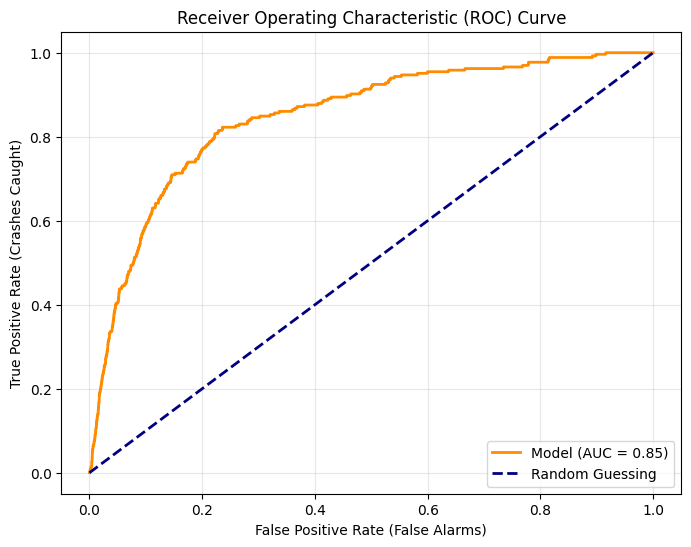


Sample Successful 'Bubble Bursts' Predicted:
      Date          Stock   Signal  Return_Next_Month
2008-03-07 DXCM UW Equity 0.900778          -0.333333
2008-03-10 DXCM UW Equity 0.888453          -0.300826
2008-09-12  AIG UN Equity 0.702189          -0.832784
2008-09-22  AIG UN Equity 0.595442          -0.470339
2008-09-23  AIG UN Equity 0.791557          -0.500000
2008-10-06  AIG UN Equity 0.902924          -0.335917
2008-10-20 INCY UW Equity 1.000000          -0.345009
2008-10-20  AIG UN Equity 0.795034          -0.415584
2008-10-21 INCY UW Equity 1.000000          -0.341549
2008-10-21  AIG UN Equity 0.752873          -0.389140


In [ ]:
evaluate_predictive_power(new_results, test_prices, forward_window=5, crash_threshold=-0.30)